In [ ]:
from google.colab import output
output.enable_custom_widget_manager()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_excel('master_dataset_2018 (1).xlsx')
df = df.ffill()
df

,Date,C5_rate_USD_tonne,C5_FFA_C5_1MON,C5_FFA_C5_2MON,C3_FFA_C3_1MON,C3_FFA_C3_2MON,China_M2_bn_USD,China_New_Loan_bn_CNY,China_Property_Price_YoY,USD_Index_DXY,...,TF_AUS_CHN_Coal_MT,TF_AUS_CHN_Bauxite_MT,TF_AUS_JPN_IronOre_MT,TF_AUS_SKorea_IronOre_MT,TF_AUS_Taiwan_IronOre_MT,TF_Brazil_CHN_IronOre_MT,TF_Brazil_SKorea_IronOre_MT,TF_Brazil_Taiwan_IronOre_MT,China_Finance_Initiation_CNY_bn,China_CrudeSteel_Prod_Mtpd_CITI
0,2018-02-01,6.445,6.783,7.133,14.850,15.383,27363.16,2897.90,5.39,88.671,...,307015,96835,171922,387400,289670,168188,173876,158106,676.954219,70.5
1,2018-02-02,6.264,6.900,7.200,14.933,15.500,27363.16,2897.90,5.39,89.195,...,134362,96835,171922,200026,289670,169730,173876,158106,676.954219,70.5
2,2018-02-05,6.245,6.900,7.183,15.067,15.550,27363.16,2897.90,5.39,89.554,...,276054,96835,201605,199322,143750,517982,196581,158106,676.954219,70.5
3,2018-02-06,6.655,6.983,7.233,15.283,15.783,27363.16,2897.90,5.39,89.585,...,313032,96835,201605,184705,143750,517982,196581,158106,676.954219,70.5
4,2018-02-07,6.691,7.050,7.267,15.383,15.883,27363.16,2897.90,5.39,90.255,...,447435,96835,196905,200146,143750,517982,196581,158106,676.954219,70.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2055,2025-12-18,10.500,8.200,7.183,20.480,18.645,47636.35,394.01,-2.78,98.427,...,607905,281637,201573,201626,138034,390975,200801,163275,676.954219,70.5
2056,2025-12-19,10.095,8.200,7.210,20.538,18.700,47636.35,394.01,-2.78,98.599,...,432564,115519,201573,201626,138034,365907,200801,163275,676.954219,70.5
2057,2025-12-22,9.795,8.217,7.320,20.557,18.870,47636.35,394.01,-2.78,98.286,...,356689,96413,201573,201626,138034,172864,200801,163275,676.954219,70.5
2058,2025-12-23,8.745,8.107,7.250,20.625,18.858,47636.35,394.01,-2.78,97.942,...,938585,96413,201573,196837,138034,1021272,200801,163275,676.954219,70.5


In [ ]:
volume = pd.read_excel('balticCape C5 FFA Volumes Daily FFADV_C5 010118 010426 040226 (2).xlsx')
volume['Date'] = pd.to_datetime(volume['Date'])
volume
df_main = df.merge(volume, on='Date', how='left')
df_main['price_volume'] = df_main['C5_rate_USD_tonne'] * df_main['Value']
windows = [7, 30, 60]

for w in windows:
    df_main[f'vwap_{w}d'] = (
        df_main['price_volume'].rolling(w).sum() /
        df_main['Value'].rolling(w).sum()
    )

df_main
df = df_main.copy()

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# LAG SCHEDULES
# ─────────────────────────────────────────────────────────────────────────────

C5_AR_LAGS = [1, 2, 3, 5, 10, 21, 42, 62]

FFA_LAGS = {
    "C5_FFA_C5_1MON": [1, 5, 21],
    "C5_FFA_C5_2MON": [1, 5, 21],
    "C3_FFA_C3_1MON": [1, 5, 21],
    "C3_FFA_C3_2MON": [1, 5, 21],
}

MACRO_MONTHLY_LAGS = {
    "China_M2_bn_USD":                 [21, 42, 62],
    "China_New_Loan_bn_CNY":            [21, 42, 62],
    "China_Property_Price_YoY":         [21, 42, 62],
    "China_PMI_Official":               [21, 42],
    "China_IP_YoY_pct":                 [21, 42, 62],
    "Japan_IP_YoY_pct":                 [21, 42, 62],
    "SouthKorea_IP_YoY_pct":            [21, 42, 62],
    "China_PBOC_Rate_pct":              [1, 5, 21],
    "China_Finance_Initiation_CNY_bn":  [21, 42, 62],
    "China_LPI_Value":                  [21, 42, 62],
    "China_Mainland_TPU":               [21, 42, 62],
}

STEEL_MONTHLY_LAGS = {
    "China_Steel_Prod_kt":              [21, 42, 62],
    "Japan_Steel_Prod_kt":              [21, 42],
    "SouthKorea_Steel_Prod_kt":         [21, 42],
    "China_BFI_Prod_kt":                [21, 42, 62],
    "Japan_BFI_Prod_kt":                [21, 42],
    "Korea_BFI_Prod_kt":                [21, 42],
    "China_CrudeSteel_Prod_10kt":       [21, 42, 62],
    "China_CrudeSteel_YoY_pct":         [21, 42],
    "China_PigIron_Prod_10kt":          [21, 42],
    "China_PigIron_YoY_pct":            [21, 42],
    "China_Rebar_Prod_10kt":            [21, 42],
    "China_Rebar_YoY_pct":              [21, 42],
    "China_CrudeSteel_Prod_Mtpd_CITI":  [21, 42],
    "China_IronOre_Prod_monthly_10kt":  [21, 42, 62],
    "China_IronOre_Prod_YoY_pct":       [21, 42],
    "CNBS_IronOre_Prod_10kt":           [21, 42],
    "CNBS_IronOre_YoY_pct":             [21, 42],
    "CITIsteel_PMI":                    [21, 42],
    "CITIsteel_Production":             [21, 42],
    "CITIsteel_NewOrders":              [21, 42],
    "CITIsteel_ExportOrders":           [21, 42],
    "CITI_SteelProd_national_10mt":     [21, 42],
    "CITI_SteelProd_key_Mtpd":          [21, 42],
}

IRONORE_LAGS = {
    "IronOre_Spot_CFR_NChina_USD_t":    [1, 5, 21, 42],
    "CITI_IronOre_CFR62_USD_t":         [1, 5, 21, 42],
    "CITI_IronOreSpot_MB_USD_t":        [1, 5, 21],
    "China_IronOre_Stockpile_kt":       [5, 10, 21, 42],
    "CITI_OreInv_ports_Mt":             [5, 10, 21, 42],
    "CITI_OreInv_AUS_Mt":               [5, 10, 21],
    "CITI_OreInv_BRA_Mt":               [5, 10, 21],
    "CITI_OreInv_days_mills":           [5, 10, 21],
}

SEABORNE_LAGS = {
    "AUS_IronOre_Seaborne_Exports_Mt_SIN":   [21, 42, 62],
    "China_IronOre_Seaborne_Imports_Mt_SIN": [21, 42, 62],
    "China_Coal_Seaborne_Imports_Mt_SIN":    [21, 42],
    "China_Steel_Seaborne_Exports_Mt_SIN":   [21, 42],
    "AUS_IronOre_Exports_Mt_CLRK":           [21, 42, 62],
    "Brazil_IronOre_Exports_Mt_CLRK":        [21, 42, 62],
    "China_IronOre_Imports_Mt_CLRK":         [21, 42, 62],
    "SKorea_IronOre_Imports_Mt_CLRK":        [21, 42],
    "Japan_IronOre_Imports_Mt_CLRK":         [21, 42],
    "China_Steel_Exports_Mt_CLRK":           [21, 42],
    "TF_AUS_CHN_IronOre_MT":                 [1, 5, 10, 21, 42],
    "TF_AUS_CHN_Coal_MT":                    [1, 5, 10, 21],
    "TF_AUS_CHN_Bauxite_MT":                 [1, 5, 10, 21],
    "TF_AUS_JPN_IronOre_MT":                 [1, 5, 10, 21],
    "TF_AUS_SKorea_IronOre_MT":              [1, 5, 10],
    "TF_AUS_Taiwan_IronOre_MT":              [1, 5, 10],
    "TF_Brazil_CHN_IronOre_MT":              [1, 5, 21, 42],
    "TF_Brazil_SKorea_IronOre_MT":           [1, 5, 21],
    "TF_Brazil_Taiwan_IronOre_MT":           [1, 5, 21],
    "Guinea_CHN_Bauxite_Import_MT":          [1, 5, 21],
    "Guinea_Bauxite_Cape_Export_MT":         [1, 5, 21],
}

FLEET_LAGS = {
    "Cape_Fleet_DWT_mn_SIN":        [21, 42, 62],
    "Cape_Fleet_Growth_YoY_pct":    [21, 42, 62],
    "Cape_Deliveries_No_SIN":       [21, 42],
    "Cape_AvgSpeed_knots":          [1, 5, 10, 21],
    "Cape_Atlantic_Ships_No":       [1, 5, 10, 21],
    "Cape_Pacific_Ships_No":        [1, 5, 10, 21],
    "Cape_Atlantic_at_sea_ballast": [1, 5, 10, 21],
    "Cape_Atlantic_at_sea_laden":   [1, 5, 10],
    "Cape_Indian_at_sea_ballast":   [1, 5, 10, 21],
    "Cape_Indian_at_sea_laden":     [1, 5, 10],
    "Cape_Pacific_at_sea_ballast":  [1, 5, 10, 21],
    "Cape_Pacific_at_sea_laden":    [1, 5, 10],
}

PORT_LAGS = {
    "Cape_PortCongestion_pct_fleet": [1, 5, 10, 21],
    "Cape_PortCongestion_CHN_mDWT":  [1, 5, 10, 21],
    "AUS_Port1_at_port":             [1, 5, 10],
    "AUS_Port1_waiting":             [1, 5, 10],
    "CHN_Port1_at_port":             [1, 5, 10],
    "CHN_Port1_waiting":             [1, 5, 10],
}

BUNKER_LAGS = {
    "Platts_HFO380_SIN_ext_USD_t":  [1, 5, 21],
    "Platts_IFO380_SIN_USD_t":      [1, 5, 21],
    "Platts_VLSFO_SIN_ext_USD_t":   [1, 5, 21],
    "Platts_VLSFO_SIN_USD_t":       [1, 5, 21],
    "Bunker_HSFO380_CLRK_W_USD_t":  [1, 5, 21],
    "Bunker_VLSFO_CLRK_W_USD_t":    [1, 5, 21],
    "Bunker_MGO_CLRK_W_USD_t":      [1, 5, 21],
    "Bunker_HSFO380_SIN_USD_t":     [1, 5],
    "Bunker_VLSFO_SIN_USD_t":       [1, 5],
    "Bunker_MGO_SIN_USD_t":         [1, 5],
}

ENERGY_LAGS = {
    "Brent_Crude_USD_bbl":          [1, 5, 21],
    "Brent_1M_USD_bbl_SIN":         [1, 5, 21],
    "Coal_Price_AUS_USD_t":         [1, 5, 21, 42],
    "ThermalCoal_FOB_AUS_USD_t":    [5, 21, 42],
    "Aluminum_LME_USD_t":           [1, 5, 21],
    "Wheat_CBOT_USdc_bu":           [1, 5, 21],
    "Copper_LME_USD_t":             [1, 5, 21],
    "MSCI_WorldEnergy":             [1, 5, 21],
}

STEEL_PRICE_LAGS = {
    "Steel_Rebar_CNY_t":                    [1, 5, 21],
    "China_SteelPlate_CNY_t":               [1, 5, 21],
    "China_SteelPlate_USD_t":               [1, 5, 21],
    "Japan_Steel_ShipPlate_USD_t":          [1, 5, 21, 42],
    "Korea_Steel_ShipPlate_USD_t":          [1, 5, 21, 42],
    "CITI_ShanghaiCoke_CNY_t":              [1, 5, 21],
    "CITI_CokingCoal_Shanxi_Liulin_#4":     [1, 5, 21],
    "CITI_Rebar_Shanghai_CNY_t":            [1, 5, 21],
    "CITI_China_Rebar12mm_CNY_t":           [1, 5, 21],
    "CITI_China_HRC3mm_CNY_t":              [1, 5, 21],
    "CITI_China_Billet_Q235_CNY_t":         [1, 5, 21],
    "CITI_Steel_SEA_USD_t":                 [1, 5, 21],
    "CITI_Steel_US_USD_t":                  [1, 5, 21],
    "CITI_AppConsump_Rebar_Mt":             [5, 21, 42],
    "CITI_AppConsump_Total_Mt":             [5, 21, 42],
}

FX_LAGS = {
    "AUDUSD_SIN":    [1, 5, 21],
    "EURUSD_SIN":    [1, 5, 21],
    "CNYUSD_SIN":    [1, 5, 21],
    "USD_Index_DXY": [1, 5, 21],
    "EURUSD":        [1, 5],
    "CNYUSD":        [1, 5],
    "AUDUSD":        [1, 5],
}

SENTIMENT_LAGS = {
    "VIX":          [1, 5, 21],
    "VHSI":         [1, 5, 21],
    "VSTOXX":       [1, 5, 21],
    "HangSeng":     [1, 5, 21],
    "SP500":        [1, 5, 21],
    "KOSPI":        [1, 5, 21],
    "MSCI_EM":      [1, 5, 21],
    "MSCI_Global":  [1, 5, 21],
    "Nikkei225":    [1, 5, 21],
    "EuroStoxx50":  [1, 5, 21],
}

ALL_EXTERNAL_LAGS = {}
for _d in [FFA_LAGS, MACRO_MONTHLY_LAGS, STEEL_MONTHLY_LAGS, IRONORE_LAGS,
           SEABORNE_LAGS, FLEET_LAGS, PORT_LAGS, BUNKER_LAGS, ENERGY_LAGS,
           STEEL_PRICE_LAGS, FX_LAGS, SENTIMENT_LAGS]:
    ALL_EXTERNAL_LAGS.update(_d)


# ─────────────────────────────────────────────────────────────────────────────
# TECHNICAL INDICATORS  (all trailing windows, zero look-ahead)
# ─────────────────────────────────────────────────────────────────────────────

def add_technical_indicators(df, price_col="C5_rate_USD_tonne", prefix=""):
    p  = df[price_col].copy()
    px = prefix if prefix else ("" if price_col == "C5_rate_USD_tonne" else f"{price_col}_")

    for span in [5, 12, 26, 50]:
        df[f"{px}EMA_{span}"] = p.ewm(span=span, adjust=False).mean()

    ema12 = p.ewm(span=12, adjust=False).mean()
    ema26 = p.ewm(span=26, adjust=False).mean()
    df[f"{px}MACD"]        = ema12 - ema26
    df[f"{px}MACD_signal"] = df[f"{px}MACD"].ewm(span=9, adjust=False).mean()
    df[f"{px}MACD_hist"]   = df[f"{px}MACD"] - df[f"{px}MACD_signal"]

    delta = p.diff()
    gain  = delta.where(delta > 0, 0.0).ewm(com=13, adjust=False).mean()
    loss  = (-delta.where(delta < 0, 0.0)).ewm(com=13, adjust=False).mean()
    rs    = gain / loss.replace(0, np.nan)
    df[f"{px}RSI_14"] = 100 - (100 / (1 + rs))

    for w in [14, 21]:
        lo      = p.rolling(w).min()
        hi      = p.rolling(w).max()
        stoch_k = 100 * (p - lo) / (hi - lo).replace(0, np.nan)
        df[f"{px}Stoch_K_{w}"] = stoch_k
        df[f"{px}Stoch_D_{w}"] = stoch_k.rolling(3).mean()

    for w in [20, 40]:
        mid = p.rolling(w).mean()
        std = p.rolling(w).std()
        df[f"{px}BB_mid_{w}"]   = mid
        df[f"{px}BB_upper_{w}"] = mid + 2 * std
        df[f"{px}BB_lower_{w}"] = mid - 2 * std
        df[f"{px}BB_width_{w}"] = (4 * std) / mid.replace(0, np.nan)
        df[f"{px}BB_pct_{w}"]   = (p - (mid - 2 * std)) / (4 * std).replace(0, np.nan)

    log_ret = np.log(p / p.shift(1))
    for w in [5, 10, 21, 42]:
        df[f"{px}RealVol_{w}d"] = log_ret.rolling(w).std() * np.sqrt(252)

    for lag in [5, 10, 21, 42, 62]:
        df[f"{px}MOM_{lag}d"] = p - p.shift(lag)
        df[f"{px}ROC_{lag}d"] = p.pct_change(lag)

    for w in [21, 63]:
        roll_mean = p.rolling(w).mean()
        roll_std  = p.rolling(w).std()
        df[f"{px}Zscore_{w}d"] = (p - roll_mean) / roll_std.replace(0, np.nan)

    df[f"{px}PctFrom52wHigh"]    = p / p.rolling(252).max() - 1
    df[f"{px}PctFrom52wLow"]     = p / p.rolling(252).min() - 1
    df[f"{px}Spread_EMA12_EMA26"]= df[f"{px}EMA_12"] - df[f"{px}EMA_26"]
    df[f"{px}Dist_from_EMA26"]   = (p - df[f"{px}EMA_26"]) / df[f"{px}EMA_26"].replace(0, np.nan)

    return df


# ─────────────────────────────────────────────────────────────────────────────
# CROSS / SPREAD FEATURES
# ─────────────────────────────────────────────────────────────────────────────

def add_cross_indicators(df):
    for col in ["C5_FFA_C5_1MON", "C5_FFA_C5_2MON"]:
        if col in df.columns:
            df[f"C5_vs_{col}_spread"]  = df["C5_rate_USD_tonne"] - df[col]
            df[f"C5_vs_{col}_pct_gap"] = df["C5_rate_USD_tonne"] / df[col].replace(0, np.nan) - 1

    if "IronOre_Spot_CFR_NChina_USD_t" in df.columns and "Platts_HFO380_SIN_ext_USD_t" in df.columns:
        df["IronOre_vs_Bunker_ratio"] = (
            df["IronOre_Spot_CFR_NChina_USD_t"] / df["Platts_HFO380_SIN_ext_USD_t"].replace(0, np.nan)
        )

    if "Brent_Crude_USD_bbl" in df.columns and "Platts_HFO380_SIN_ext_USD_t" in df.columns:
        df["Brent_vs_HFO_spread"] = df["Brent_Crude_USD_bbl"] * 7.45 - df["Platts_HFO380_SIN_ext_USD_t"]

    for region in ["Atlantic", "Pacific"]:
        l_col = f"Cape_{region}_at_sea_laden"
        b_col = f"Cape_{region}_at_sea_ballast"
        if l_col in df.columns and b_col in df.columns:
            total = df[l_col] + df[b_col]
            df[f"Cape_{region}_utilisation"] = df[l_col] / total.replace(0, np.nan)

    for col in ["TF_AUS_CHN_IronOre_MT", "TF_Brazil_CHN_IronOre_MT"]:
        if col in df.columns:
            df[f"{col}_7d_sum"]  = df[col].rolling(7).sum()
            df[f"{col}_21d_sum"] = df[col].rolling(21).sum()
            df[f"{col}_mom_5d"]  = (
                df[col].rolling(5).sum() / df[col].rolling(21).sum().replace(0, np.nan) - 1
            )

    if "C3_FFA_C3_1MON" in df.columns and "C5_FFA_C5_1MON" in df.columns:
        df["C3_vs_C5_FFA_spread"] = df["C3_FFA_C3_1MON"] - df["C5_FFA_C5_1MON"]

    if "VIX" in df.columns and "IronOre_Spot_CFR_NChina_USD_t" in df.columns:
        df["RiskAdj_IronOre"] = df["IronOre_Spot_CFR_NChina_USD_t"] / (1 + df["VIX"] / 100)

    cong_cols = [c for c in df.columns if "PortCongestion" in c or "waiting" in c or "at_port" in c]
    if cong_cols:
        df["Total_Congestion_proxy"] = df[cong_cols].sum(axis=1, min_count=1)

    vol       = df["Volume_FFA"].fillna(0) if "Volume_FFA" in df.columns else pd.Series(1.0, index=df.index)
    direction = np.sign(df["C5_rate_USD_tonne"].diff().fillna(0))
    df["C5_OBV_proxy"] = (direction * vol).cumsum()

    return df


# ─────────────────────────────────────────────────────────────────────────────
# CALENDAR FEATURES
# ─────────────────────────────────────────────────────────────────────────────

def add_calendar_features(df):
    idx = df.index
    df["DayOfWeek"]     = idx.dayofweek
    df["MonthOfYear"]   = idx.month
    df["QuarterOfYear"] = idx.quarter
    df["WeekOfYear"]    = idx.isocalendar().week.astype(int)
    df["IsMonthEnd"]    = idx.is_month_end.astype(int)
    df["IsMonthStart"]  = idx.is_month_start.astype(int)
    df["IsQtrEnd"]      = idx.is_quarter_end.astype(int)
    df["CNY_season"]    = (((idx.month == 1) & (idx.day >= 15)) | (idx.month == 2)).astype(int)
    return df


# ─────────────────────────────────────────────────────────────────────────────
# MAIN BUILD FUNCTION
# ─────────────────────────────────────────────────────────────────────────────

def build_features(
    df,
    horizon: int = 62,
    add_tech_on_prices: list = None,
    drop_port2_monthly: bool = True,
) -> pd.DataFrame:

    # Drop Port2 month-name columns
    if drop_port2_monthly:
        month_names = ["January","February","March","April","May","June",
                       "July","August","September","October","November","December"]
        month_cols = [c for c in df.columns if any(m in c for m in month_names)]
        df.drop(columns=month_cols, inplace=True, errors="ignore")
        print(f"  Dropped {len(month_cols)} Port2 month-name columns")

    n_orig = df.shape[1]

    # 1. C5 AR lags
    print("Adding C5 AR lags...")
    for lag in C5_AR_LAGS:
        df[f"C5_lag_{lag}d"] = df["C5_rate_USD_tonne"].shift(lag)
    for lag in [1, 5, 10, 21, 42, 62]:
        df[f"C5_logret_{lag}d"] = np.log(
            df["C5_rate_USD_tonne"] / df["C5_rate_USD_tonne"].shift(lag)
        )

    # 2. External variable lags
    print("Adding external variable lags...")
    n_lag_cols = 0
    for col, lags in ALL_EXTERNAL_LAGS.items():
        if col not in df.columns:
            continue
        for lag in lags:
            df[f"{col}_lag{lag}d"] = df[col].shift(lag)
            n_lag_cols += 1
    print(f"  Added {n_lag_cols} lag columns")

    # 3. Rolling stats on key external series
    print("Adding rolling stats...")
    if "China_IronOre_Stockpile_kt" in df.columns:
        for w in [10, 21]:
            df[f"IronOreStk_chg_{w}d"] = df["China_IronOre_Stockpile_kt"].diff(w)
    for col in ["Platts_HFO380_SIN_ext_USD_t", "Bunker_HSFO380_CLRK_W_USD_t"]:
        if col in df.columns:
            for w in [21, 42]:
                df[f"{col}_roll{w}d"] = df[col].rolling(w).mean()
    if "IronOre_Spot_CFR_NChina_USD_t" in df.columns:
        for w in [21, 42]:
            df[f"IronOre_roll{w}d"] = df["IronOre_Spot_CFR_NChina_USD_t"].rolling(w).mean()
    for col in ["TF_AUS_CHN_IronOre_MT", "TF_Brazil_CHN_IronOre_MT"]:
        if col in df.columns:
            df[f"{col}_roll21d"] = df[col].rolling(21).sum()

    # 4. Technical indicators
    print("Adding technical indicators on C5...")
    df = add_technical_indicators(df, price_col="C5_rate_USD_tonne", prefix="")
    if add_tech_on_prices is None:
        add_tech_on_prices = [
            "IronOre_Spot_CFR_NChina_USD_t",
            "Brent_Crude_USD_bbl",
            "Platts_HFO380_SIN_ext_USD_t",
            "C5_FFA_C5_1MON",
        ]
    for pcol in add_tech_on_prices:
        if pcol in df.columns:
            print(f"  Technical indicators on {pcol}...")
            df = add_technical_indicators(df, price_col=pcol, prefix=f"{pcol}_")

    # 5. Cross features
    print("Adding cross features...")
    df = add_cross_indicators(df)

    # 6. Calendar features
    print("Adding calendar features...")
    df = add_calendar_features(df)

    n_added = df.shape[1] - n_orig
    print(f"\n{'='*60}")
    print(f"FEATURE BUILD COMPLETE")
    print(f"  Original columns : {n_orig}")
    print(f"  Features added   : {n_added}")
    print(f"  Total columns    : {df.shape[1]}")
    print(f"  Total rows       : {df.shape[0]}")
    print(f"{'='*60}")

    return df


# ─────────────────────────────────────────────────────────────────────────────
# FEATURE GROUP MAP
# ─────────────────────────────────────────────────────────────────────────────

def get_feature_groups(df: pd.DataFrame, horizon: int = 62) -> dict:
    exclude = {"C5_rate_USD_tonne"}

    def pick(patterns):
        return [c for c in df.columns if c not in exclude
                and any(p in c for p in patterns)]

    return {
        "c5_ar":        pick(["C5_lag_", "C5_logret_"]),
        "c5_technical": pick(["EMA_","MACD","RSI","Stoch","BB_","RealVol",
                               "MOM_","ROC_","Zscore","PctFrom52","Spread_EMA","Dist_from"]),
        "ffa":          pick(["C5_FFA","C3_FFA","C3_vs_C5","C5_vs_C5_FFA"]),
        "iron_ore":     pick(["IronOre","OreInv"]),
        "steel":        pick(["Steel","Rebar","BFI","PigIron","Coke","Billet","HRC"]),
        "seaborne":     pick(["TF_","Seaborne","_Mt_SIN","_Mt_CLRK","Guinea"]),
        "fleet_supply": pick(["Cape_","utilisation","Total_Congestion"]),
        "bunker":       pick(["Bunker","Platts","IFO","VLSFO","HFO","MGO"]),
        "energy":       pick(["Brent","Coal_Price","Aluminum","Wheat","WorldEnergy"]),
        "fx":           pick(["AUDUSD","EURUSD","CNYUSD","USD_Index"]),
        "macro":        pick(["China_M2","New_Loan","Property","PMI","IP_YoY",
                               "PBOC","Finance_Init","LPI","TPU"]),
        "sentiment":    pick(["VIX","VHSI","VSTOXX","SP500","HangSeng","KOSPI",
                               "MSCI","Nikkei","EuroStoxx","RiskAdj"]),
        "calendar":     pick(["DayOfWeek","MonthOfYear","Quarter","WeekOfYear",
                               "IsMonth","IsQtr","CNY"]),
        "cross":        pick(["vs_","ratio","crack","_sum","_mom_","OBV","Congestion_proxy"]),
    }

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").set_index("Date")
df_feat = build_features(df, horizon=62)

df = df_feat.copy()
df = df.ffill()
df = df.dropna()
df

  Dropped 24 Port2 month-name columns
Adding C5 AR lags...
Adding external variable lags...
  Added 314 lag columns
Adding rolling stats...
Adding technical indicators on C5...
  Technical indicators on IronOre_Spot_CFR_NChina_USD_t...
  Technical indicators on Brent_Crude_USD_bbl...
  Technical indicators on Platts_HFO380_SIN_ext_USD_t...
  Technical indicators on C5_FFA_C5_1MON...
Adding cross features...
Adding calendar features...

FEATURE BUILD COMPLETE
  Original columns : 118
  Features added   : 572
  Total columns    : 690
  Total rows       : 2060


,C5_rate_USD_tonne,C5_FFA_C5_1MON,C5_FFA_C5_2MON,C3_FFA_C3_1MON,C3_FFA_C3_2MON,China_M2_bn_USD,China_New_Loan_bn_CNY,China_Property_Price_YoY,USD_Index_DXY,China_PMI_Official,...,Total_Congestion_proxy,C5_OBV_proxy,DayOfWeek,MonthOfYear,QuarterOfYear,WeekOfYear,IsMonthEnd,IsMonthStart,IsQtrEnd,CNY_season
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-18,6.955,6.517,6.800,15.633,15.900,26557.30,1083.94,10.56,96.336,49.5,...,276.89811,-15.0,4,1,1,3,0,0,0,1
2019-01-21,6.727,6.467,6.733,15.567,15.833,26557.30,1083.94,10.56,96.336,49.5,...,277.60731,-16.0,0,1,1,4,0,0,0,1
2019-01-22,6.341,6.383,6.667,15.433,15.750,26557.30,1083.94,10.56,96.303,49.5,...,276.34837,-17.0,1,1,1,4,0,0,0,1
2019-01-23,6.091,6.383,6.667,15.433,15.750,26557.30,1083.94,10.56,96.123,49.5,...,276.02908,-18.0,2,1,1,4,0,0,0,1
2019-01-24,6.064,6.283,6.600,15.433,15.750,26557.30,1083.94,10.56,96.601,49.5,...,276.90732,-19.0,3,1,1,4,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-18,10.500,8.200,7.183,20.480,18.645,47636.35,394.01,-2.78,98.427,49.2,...,307.55725,-117.0,3,12,4,51,0,0,0,0
2025-12-19,10.095,8.200,7.210,20.538,18.700,47636.35,394.01,-2.78,98.599,49.2,...,307.86004,-118.0,4,12,4,51,0,0,0,0
2025-12-22,9.795,8.217,7.320,20.557,18.870,47636.35,394.01,-2.78,98.286,49.2,...,306.92499,-119.0,0,12,4,52,0,0,0,0


In [ ]:
regime_pred = pd.read_excel('c5_regime_results_to_add.xlsx')

# Ensure datetime format
regime_pred['Date'] = pd.to_datetime(regime_pred['Date'])

# Sort
df = df.sort_values('Date')
regime_pred = regime_pred.sort_values('Date')

regime_pred = regime_pred.drop(columns=['C5_rate_USD_tonne'])
df_main = pd.merge(df, regime_pred, on='Date', how='left')
df_main = df_main.ffill()
df_main = df_main.dropna()
df_main

df_main = df_main.copy()
df_main["Date"] = pd.to_datetime(df_main["Date"]) if "Date" in df_main.columns else df_main.index
df_main = df_main.set_index("Date") if "Date" in df_main.columns else df_main
df_main.index = pd.to_datetime(df_main.index)

In [ ]:

import numpy as np
import pandas as pd
import time
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model    import Ridge
from sklearn.multioutput     import MultiOutputRegressor
from sklearn.decomposition   import PCA
from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.isotonic        import IsotonicRegression
from scipy                   import stats


# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────

HORIZON    = 62     # forecast horizons h = 1…62
MIN_TRAIN  = 252    # min training days before first OOS origin
STEP       = 63     # walk-forward step — ~24 origins total (~30s runtime)
TARGET_COL = "C5_rate_USD_tonne"
N_PCA      = 27     # PCA components to keep

Z_80 = stats.norm.ppf(0.90)    # 1.282
Z_95 = stats.norm.ppf(0.975)   # 1.960


# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — TARGET ENGINEERING
# ─────────────────────────────────────────────────────────────────────────────

def build_targets(df: pd.DataFrame, horizon: int = HORIZON) -> pd.DataFrame:
    """
    y_{t,h} = log(C5_{t+h} / C5_t)  for h = 1…62
    Returns shape (n_dates, 62). Future rows → NaN.
    """
    prices  = df[TARGET_COL].values
    n       = len(prices)
    targets = np.full((n, horizon), np.nan)
    for h in range(1, horizon + 1):
        targets[:n - h, h - 1] = np.log(prices[h:] / prices[:n - h])
    cols = [f"target_h{h}" for h in range(1, horizon + 1)]
    return pd.DataFrame(targets, index=df.index, columns=cols)


# ─────────────────────────────────────────────────────────────────────────────
# FEATURE SELECTION
# ─────────────────────────────────────────────────────────────────────────────

def get_feature_cols(df: pd.DataFrame) -> list:
    exclude = {TARGET_COL}
    exclude.update([c for c in df.columns if c.startswith("target_h")])
    return [c for c in df.columns
            if c not in exclude and pd.api.types.is_numeric_dtype(df[c])]


# ─────────────────────────────────────────────────────────────────────────────
# MODEL — StandardScaler + PCA + Ridge (multi-output)
# ─────────────────────────────────────────────────────────────────────────────

def make_model(n_pca: int = N_PCA) -> Pipeline:
    """
    Pipeline:  StandardScaler → PCA(n_pca) → Ridge(alpha=1.0) [multi-output]
    Fits all 62 horizons in one call. Runs in milliseconds per origin.
    """
    return Pipeline([
        ("scaler", StandardScaler()),
        ("pca",    PCA(n_components=n_pca, random_state=42)),
        ("ridge",  Ridge(alpha=1.0, fit_intercept=True)),
    ])


# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — WALK-FORWARD POINT FORECASTS (μ_h)
# ─────────────────────────────────────────────────────────────────────────────

def walk_forward_forecasts(
    df        : pd.DataFrame,
    targets   : pd.DataFrame,
    horizon   : int = HORIZON,
    min_train : int = MIN_TRAIN,
    step      : int = STEP,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Expanding-window walk-forward.
    ONE model fit per origin → predicts all 62 horizons simultaneously.
    With step=63: ~24 fits total, runtime ~20-30s.
    """
    feature_cols = get_feature_cols(df)
    X  = df[feature_cols].values.astype(np.float32)
    Y  = targets.values                              # (n, 62)
    n  = len(df)

    origins   = list(range(min_train, n - horizon, step))
    n_origins = len(origins)
    mu_mat    = np.full((n_origins, horizon), np.nan)
    act_mat   = np.full((n_origins, horizon), np.nan)
    idx_list  = []

    print(f"Walk-forward: {n_origins} origins | step={step} | min_train={min_train}")
    print(f"Model: StandardScaler → PCA({N_PCA}) → Ridge  [all 62 horizons at once]")
    t0 = time.time()

    for i, t in enumerate(origins):
        idx_val  = df.index[t]
        date_str = idx_val.date() if hasattr(idx_val, "date") else str(idx_val)[:10]

        X_tr = X[:t]
        Y_tr = Y[:t]

        # Keep rows where ALL 62 targets are non-NaN
        valid = ~np.isnan(Y_tr).any(axis=1)
        # Also drop NaN features
        valid &= ~np.isnan(X_tr).any(axis=1)

        if valid.sum() < 60:
            idx_list.append(idx_val)
            continue

        model = make_model()
        model.fit(X_tr[valid], Y_tr[valid])

        x_t = X[t]
        if np.isnan(x_t).any():
            idx_list.append(idx_val)
            continue

        mu_mat[i]  = model.predict(x_t.reshape(1, -1))[0]
        act_mat[i] = Y[t]

        elapsed = time.time() - t0
        eta     = (elapsed / (i + 1)) * (n_origins - i - 1)
        print(f"  [{i+1:2d}/{n_origins}] {date_str}  "
              f"elapsed={elapsed:.1f}s  ETA={eta:.1f}s")
        idx_list.append(idx_val)

    h_cols = [f"h{h}" for h in range(1, horizon + 1)]
    mu_df  = pd.DataFrame(mu_mat,  index=idx_list, columns=h_cols)
    act_df = pd.DataFrame(act_mat, index=idx_list, columns=h_cols)
    print(f"\nDone. Total: {time.time()-t0:.1f}s | Shape: {mu_df.shape}")
    return mu_df, act_df


# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 — CALIBRATE σ_h (monotone)
# ─────────────────────────────────────────────────────────────────────────────

def calibrate_sigma(
    mu_df  : pd.DataFrame,
    act_df : pd.DataFrame,
    horizon: int = HORIZON,
) -> np.ndarray:
    """
    For each horizon h:
        e_{t,h}   = y_{t,h} - μ_{t,h}   (OOS residuals)
        σ_h       = std(e[:,h])

    Then isotonic regression enforces σ_1 ≤ σ_2 ≤ … ≤ σ_62.
    """
    h_cols    = [f"h{h}" for h in range(1, horizon + 1)]
    raw_sigma = np.zeros(horizon)

    for i, col in enumerate(h_cols):
        res = (act_df[col] - mu_df[col]).dropna().values
        raw_sigma[i] = res.std(ddof=1) if len(res) > 1 else np.nan

    iso            = IsotonicRegression(increasing=True)
    sigma_monotone = iso.fit_transform(np.arange(1, horizon + 1), raw_sigma)

    print("\nσ calibration (selected horizons):")
    print(f"  {'h':>4}  {'raw σ':>8}  {'monotone σ':>10}  {'95% band ±':>10}")
    for h in [1, 5, 10, 21, 42, 62]:
        print(f"  {h:4d}  {raw_sigma[h-1]:8.4f}  "
              f"{sigma_monotone[h-1]:10.4f}  "
              f"{Z_95 * sigma_monotone[h-1]:10.4f}")
    return sigma_monotone


# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 — LIVE FORECAST: DISTRIBUTION + LEVEL RECONSTRUCTION
# ─────────────────────────────────────────────────────────────────────────────

def forecast_distribution(
    df       : pd.DataFrame,
    sigma    : np.ndarray,
    horizon  : int = HORIZON,
    origin_t : int = -1,
) -> pd.DataFrame:
    """
    Train on full history up to origin_t, predict 62-day distribution.
    Each horizon h: N(μ_h, σ_h²) in log-return space → level via exp().
    """
    feature_cols = get_feature_cols(df)
    targets      = build_targets(df, horizon)
    X            = df[feature_cols].values.astype(np.float32)
    Y            = targets.values

    t    = origin_t if origin_t >= 0 else len(df) - 1
    C5_t = df[TARGET_COL].iloc[t]

    valid = ~np.isnan(Y[:t]).any(axis=1) & ~np.isnan(X[:t]).any(axis=1)
    model = make_model()
    model.fit(X[:t][valid], Y[:t][valid])
    mu_vec = model.predict(X[t].reshape(1, -1))[0]   # shape (62,)

    date_str = df.index[t].date() if hasattr(df.index[t], "date") else df.index[t]
    print(f"Live forecast from {date_str}, C5={C5_t:.2f}")

    rows = []
    for h in range(1, horizon + 1):
        mu_h  = mu_vec[h - 1]
        sig_h = sigma[h - 1]
        fdate = df.index[t] + pd.offsets.BDay(h)
        rows.append({
            "horizon"    : h,
            "date"       : fdate,
            "mu_logret"  : mu_h,
            "sigma_logret": sig_h,
            "C5_point"   : C5_t * np.exp(mu_h),
            "C5_lower80" : C5_t * np.exp(mu_h - Z_80 * sig_h),
            "C5_upper80" : C5_t * np.exp(mu_h + Z_80 * sig_h),
            "C5_lower95" : C5_t * np.exp(mu_h - Z_95 * sig_h),
            "C5_upper95" : C5_t * np.exp(mu_h + Z_95 * sig_h),
        })
    return pd.DataFrame(rows).set_index("horizon")


# ─────────────────────────────────────────────────────────────────────────────
# EVALUATION — CRPS + WINKLER + COVERAGE
# ─────────────────────────────────────────────────────────────────────────────

def crps_gaussian(mu: float, sigma: float, y: float) -> float:
    if sigma <= 0 or np.isnan(y):
        return np.nan
    z   = (y - mu) / sigma
    return sigma * (z * (2 * stats.norm.cdf(z) - 1) +
                    2 * stats.norm.pdf(z) - 1 / np.sqrt(np.pi))


def winkler_score(lo, hi, y, alpha):
    width = hi - lo
    if y < lo:  return width + (2 / alpha) * (lo - y)
    if y > hi:  return width + (2 / alpha) * (y - hi)
    return width


def evaluate(
    mu_df  : pd.DataFrame,
    act_df : pd.DataFrame,
    sigma  : np.ndarray,
    horizon: int = HORIZON,
) -> pd.DataFrame:
    records = []
    for h in range(1, horizon + 1):
        col     = f"h{h}"
        sig_h   = sigma[h - 1]
        mu_v    = mu_df[col].dropna()
        act_v   = act_df[col].reindex(mu_v.index).dropna()
        mu_v    = mu_v.reindex(act_v.index)
        if len(act_v) == 0:
            continue

        crps = [crps_gaussian(m, sig_h, y) for m, y in zip(mu_v, act_v)]
        lo80 = mu_v - Z_80 * sig_h;  hi80 = mu_v + Z_80 * sig_h
        lo95 = mu_v - Z_95 * sig_h;  hi95 = mu_v + Z_95 * sig_h
        w80  = [winkler_score(l, u, y, 0.20) for l, u, y in zip(lo80, hi80, act_v)]
        w95  = [winkler_score(l, u, y, 0.05) for l, u, y in zip(lo95, hi95, act_v)]

        records.append({
            "horizon"   : h,
            "sigma"     : sig_h,
            "CRPS"      : np.nanmean(crps),
            "Winkler_80": np.nanmean(w80),
            "Winkler_95": np.nanmean(w95),
            "Coverage_80": ((act_v >= lo80) & (act_v <= hi80)).mean(),
            "Coverage_95": ((act_v >= lo95) & (act_v <= hi95)).mean(),
            "MAE_logret": (mu_v - act_v).abs().mean(),
            "n_obs"     : len(act_v),
        })
    return pd.DataFrame(records).set_index("horizon")


# ─────────────────────────────────────────────────────────────────────────────
# MAIN PIPELINE
# ─────────────────────────────────────────────────────────────────────────────

def run_probabilistic_pipeline(df: pd.DataFrame) -> dict:
    # Ensure DatetimeIndex
    if not isinstance(df.index, pd.DatetimeIndex):
        if "Date" in df.columns:
            df = df.set_index("Date")
        df.index = pd.to_datetime(df.index)

    print("=" * 60)
    print("STEP 1 — Building targets")
    print("=" * 60)
    targets = build_targets(df)
    print(f"Target matrix shape: {targets.shape}")

    print("\n" + "=" * 60)
    print("STEP 2 — Walk-forward point forecasts (Ridge + PCA)")
    print("=" * 60)
    mu_df, act_df = walk_forward_forecasts(df, targets)

    print("\n" + "=" * 60)
    print("STEP 3 — Calibrating σ_h (monotone)")
    print("=" * 60)
    sigma = calibrate_sigma(mu_df, act_df)

    print("\n" + "=" * 60)
    print("STEP 4 — Evaluation")
    print("=" * 60)
    eval_df = evaluate(mu_df, act_df, sigma)
    print("\nKey horizons:")
    print(eval_df.loc[eval_df.index.isin([1, 5, 10, 21, 42, 62])].to_string())

    print("\n" + "=" * 60)
    print("STEP 4b — Live 62-day distribution forecast")
    print("=" * 60)
    forecast = forecast_distribution(df, sigma)
    print(forecast[["C5_point","C5_lower80","C5_upper80",
                     "C5_lower95","C5_upper95"]].iloc[[0,4,9,20,41,61]])

    return {
        "mu_df"   : mu_df,
        "act_df"  : act_df,
        "sigma"   : sigma,
        "eval_df" : eval_df,
        "forecast": forecast,
    }


# ─────────────────────────────────────────────────────────────────────────────
# USAGE
# ─────────────────────────────────────────────────────────────────────────────
# results = run_probabilistic_pipeline(df_main)


# ─────────────────────────────────────────────────────────────────────────────
# PLOT — 62-day uncertainty cone
# ─────────────────────────────────────────────────────────────────────────────

def plot_forecast(
    df      : pd.DataFrame,
    forecast: pd.DataFrame,
    history_days: int = 120,
) -> None:
    """
    Plot the 62-day probabilistic forecast cone with:
      - historical C5 (last history_days business days)
      - point forecast (median)
      - 80% and 95% prediction bands
      - sigma growth subplot
    """
    import matplotlib.pyplot as plt
    import matplotlib.dates  as mdates

    # ── historical window ──────────────────────────────────────────────────
    hist = df[TARGET_COL].iloc[-history_days:]

    # ── forecast series ────────────────────────────────────────────────────
    dates   = pd.to_datetime(forecast["date"])
    point   = forecast["C5_point"]
    lo80    = forecast["C5_lower80"]
    hi80    = forecast["C5_upper80"]
    lo95    = forecast["C5_lower95"]
    hi95    = forecast["C5_upper95"]
    sigmas  = forecast["sigma_logret"]

    # ── figure ─────────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize     = (13, 8),
        gridspec_kw = {"height_ratios": [3, 1]},
        facecolor   = "#0f1117",
    )
    fig.suptitle(
        f"C5 Capesize — 62-day probabilistic forecast  "
        f"(origin: {hist.index[-1].date() if hasattr(hist.index[-1], 'date') else str(hist.index[-1])[:10]})",
        color="#e0e0e0", fontsize=13, fontweight="bold", y=0.98,
    )

    for ax in (ax1, ax2):
        ax.set_facecolor("#0f1117")
        ax.tick_params(colors="#888", labelsize=9)
        for spine in ax.spines.values():
            spine.set_edgecolor("#333")

    # ── ax1 : price + cone ─────────────────────────────────────────────────
    # 95% band
    ax1.fill_between(dates, lo95, hi95,
                     color="#3b5bdb", alpha=0.18, label="95% band")
    # 80% band
    ax1.fill_between(dates, lo80, hi80,
                     color="#3b5bdb", alpha=0.32, label="80% band")
    # point forecast
    ax1.plot(dates, point,
             color="#74c0fc", linewidth=1.8, label="Point forecast (median)")
    # historical
    ax1.plot(hist.index, hist.values,
             color="#e0e0e0", linewidth=1.4, label="Historical C5")
    # vertical line at origin
    ax1.axvline(hist.index[-1], color="#555", linewidth=1, linestyle="--")

    # origin dot
    ax1.scatter([hist.index[-1]], [hist.values[-1]],
                color="white", s=40, zorder=5)

    ax1.set_ylabel("C5 rate (USD/tonne)", color="#aaa", fontsize=10)
    ax1.yaxis.label.set_color("#aaa")
    ax1.legend(
        loc="upper left", framealpha=0.2,
        labelcolor="#ccc", fontsize=9, facecolor="#1a1a2e",
    )
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax1.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha="right")
    ax1.grid(axis="y", color="#222", linewidth=0.5)
    ax1.grid(axis="x", color="#1a1a1a", linewidth=0.5)

    # ── ax2 : sigma growth ─────────────────────────────────────────────────
    ax2.plot(dates, sigmas,
             color="#f59f00", linewidth=1.6, label="σ_h (log-return)")
    ax2.fill_between(dates, 0, sigmas, color="#f59f00", alpha=0.15)
    ax2.set_ylabel("σ_h", color="#aaa", fontsize=10)
    ax2.set_xlabel("Date", color="#aaa", fontsize=10)
    ax2.yaxis.label.set_color("#aaa")
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax2.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")
    ax2.grid(axis="y", color="#222", linewidth=0.5)
    ax2.grid(axis="x", color="#1a1a1a", linewidth=0.5)
    ax2.set_title("Uncertainty growth  (σ_h monotone increasing)",
                  color="#888", fontsize=9, pad=4)

    plt.tight_layout()
    plt.savefig("c5_forecast_cone.png", dpi=150,
                bbox_inches="tight", facecolor="#0f1117")
    plt.show()
    print("Plot saved → c5_forecast_cone.png")


# ─────────────────────────────────────────────────────────────────────────────
# PLOT — distribution at each horizon (interactive slider)
# ─────────────────────────────────────────────────────────────────────────────

def plot_distributions(
    df      : pd.DataFrame,
    forecast: pd.DataFrame,
) -> None:
    """
    Interactive matplotlib plot with a slider.
    At each horizon h, shows:
      - the Gaussian N(mu_h, sigma_h) in log-return space
      - the reconstructed C5 level distribution
      - 80% and 95% intervals marked
      - how sigma grows across horizons
    """
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    from matplotlib.widgets   import Slider
    from scipy.stats          import norm

    mu_vec    = forecast["mu_logret"].values      # (62,)
    sigma_vec = forecast["sigma_logret"].values   # (62,)
    dates     = pd.to_datetime(forecast["date"])
    C5_0      = df[TARGET_COL].iloc[-1]

    fig = plt.figure(figsize=(14, 7), facecolor="#0f1117")
    fig.suptitle("C5 — predictive distribution per horizon",
                 color="#e0e0e0", fontsize=12, fontweight="bold")

    gs = gridspec.GridSpec(2, 2, figure=fig,
                           left=0.07, right=0.97,
                           top=0.90, bottom=0.15,
                           hspace=0.45, wspace=0.35)

    ax_log  = fig.add_subplot(gs[0, 0])   # gaussian in log-return space
    ax_lvl  = fig.add_subplot(gs[0, 1])   # gaussian in level space
    ax_sig  = fig.add_subplot(gs[1, 0])   # sigma growth
    ax_cone = fig.add_subplot(gs[1, 1])   # mini cone with current h marked

    for ax in (ax_log, ax_lvl, ax_sig, ax_cone):
        ax.set_facecolor("#0f1117")
        ax.tick_params(colors="#888", labelsize=8)
        for spine in ax.spines.values():
            spine.set_edgecolor("#333")

    # ── sigma growth (static) ──────────────────────────────────────────────
    ax_sig.plot(range(1, 63), sigma_vec, color="#f59f00", linewidth=1.5)
    ax_sig.fill_between(range(1, 63), 0, sigma_vec,
                        color="#f59f00", alpha=0.15)
    ax_sig.set_xlabel("horizon h", color="#aaa", fontsize=8)
    ax_sig.set_ylabel("σ_h", color="#aaa", fontsize=8)
    ax_sig.set_title("uncertainty growth", color="#888", fontsize=9)
    ax_sig.grid(color="#1e1e1e", linewidth=0.5)
    sigma_marker, = ax_sig.plot([], [], "o", color="white", markersize=6, zorder=5)

    # ── mini cone (static) ────────────────────────────────────────────────
    lo95 = forecast["C5_lower95"].values
    hi95 = forecast["C5_upper95"].values
    lo80 = forecast["C5_lower80"].values
    hi80 = forecast["C5_upper80"].values
    pt   = forecast["C5_point"].values
    ax_cone.fill_between(range(1, 63), lo95, hi95,
                         color="#3b5bdb", alpha=0.18)
    ax_cone.fill_between(range(1, 63), lo80, hi80,
                         color="#3b5bdb", alpha=0.32)
    ax_cone.plot(range(1, 63), pt, color="#74c0fc", linewidth=1.2)
    ax_cone.axhline(C5_0, color="#555", linewidth=0.8, linestyle="--")
    ax_cone.set_xlabel("horizon h", color="#aaa", fontsize=8)
    ax_cone.set_ylabel("C5 (USD/t)", color="#aaa", fontsize=8)
    ax_cone.set_title("forecast cone", color="#888", fontsize=9)
    ax_cone.grid(color="#1e1e1e", linewidth=0.5)
    cone_marker = ax_cone.axvline(1, color="white", linewidth=1, linestyle=":")

    # ── draw function ──────────────────────────────────────────────────────
    def draw(h):
        h   = int(h)
        idx = h - 1
        mu  = mu_vec[idx]
        sig = sigma_vec[idx]
        d   = dates.iloc[idx]

        # log-return gaussian
        x_log = np.linspace(mu - 4 * sig, mu + 4 * sig, 400)
        y_log = norm.pdf(x_log, mu, sig)

        ax_log.cla()
        ax_log.set_facecolor("#0f1117")
        ax_log.tick_params(colors="#888", labelsize=8)
        for spine in ax_log.spines.values():
            spine.set_edgecolor("#333")

        ax_log.plot(x_log, y_log, color="#74c0fc", linewidth=2)
        ax_log.fill_between(x_log, y_log, alpha=0.15, color="#3b5bdb")

        lo80_l = mu - Z_80 * sig;  hi80_l = mu + Z_80 * sig
        lo95_l = mu - Z_95 * sig;  hi95_l = mu + Z_95 * sig

        ax_log.fill_between(x_log, y_log,
                            where=(x_log >= lo95_l) & (x_log <= hi95_l),
                            color="#3b5bdb", alpha=0.20, label="95%")
        ax_log.fill_between(x_log, y_log,
                            where=(x_log >= lo80_l) & (x_log <= hi80_l),
                            color="#3b5bdb", alpha=0.35, label="80%")
        ax_log.axvline(mu, color="#74c0fc", linewidth=1.2, linestyle="--")
        ax_log.axvline(0,  color="#555",    linewidth=0.8, linestyle=":")
        ax_log.set_title(f"log-return  h={h}  ({d.date()})",
                         color="#ccc", fontsize=9)
        ax_log.set_xlabel("log-return", color="#aaa", fontsize=8)
        ax_log.set_ylabel("density",    color="#aaa", fontsize=8)
        ax_log.legend(fontsize=8, labelcolor="#ccc",
                      facecolor="#1a1a2e", framealpha=0.3)
        ax_log.grid(color="#1e1e1e", linewidth=0.5)

        # C5 level distribution (lognormal)
        C5_mu  = C5_0 * np.exp(mu)
        C5_sig = C5_mu * sig          # delta method approximation
        x_lvl  = np.linspace(max(0.1, C5_mu - 4 * C5_sig),
                              C5_mu + 4 * C5_sig, 400)
        y_lvl  = norm.pdf(x_lvl, C5_mu, C5_sig)

        ax_lvl.cla()
        ax_lvl.set_facecolor("#0f1117")
        ax_lvl.tick_params(colors="#888", labelsize=8)
        for spine in ax_lvl.spines.values():
            spine.set_edgecolor("#333")

        ax_lvl.plot(x_lvl, y_lvl, color="#a9e34b", linewidth=2)
        ax_lvl.fill_between(x_lvl, y_lvl, alpha=0.15, color="#5c940d")

        C5_lo80 = C5_0 * np.exp(lo80_l);  C5_hi80 = C5_0 * np.exp(hi80_l)
        C5_lo95 = C5_0 * np.exp(lo95_l);  C5_hi95 = C5_0 * np.exp(hi95_l)

        ax_lvl.fill_between(x_lvl, y_lvl,
                            where=(x_lvl >= C5_lo95) & (x_lvl <= C5_hi95),
                            color="#5c940d", alpha=0.20, label="95%")
        ax_lvl.fill_between(x_lvl, y_lvl,
                            where=(x_lvl >= C5_lo80) & (x_lvl <= C5_hi80),
                            color="#5c940d", alpha=0.38, label="80%")
        ax_lvl.axvline(C5_mu, color="#a9e34b", linewidth=1.2, linestyle="--")
        ax_lvl.axvline(C5_0,  color="#555",    linewidth=0.8, linestyle=":",
                       label=f"current C5={C5_0:.2f}")
        ax_lvl.set_title(f"C5 level  h={h}  ({d.date()})",
                         color="#ccc", fontsize=9)
        ax_lvl.set_xlabel("C5 (USD/tonne)", color="#aaa", fontsize=8)
        ax_lvl.set_ylabel("density",        color="#aaa", fontsize=8)
        ax_lvl.legend(fontsize=8, labelcolor="#ccc",
                      facecolor="#1a1a2e", framealpha=0.3)
        ax_lvl.grid(color="#1e1e1e", linewidth=0.5)

        # update markers
        sigma_marker.set_data([h], [sig])
        cone_marker.set_xdata([h])
        fig.canvas.draw_idle()

    # ── slider ────────────────────────────────────────────────────────────
    ax_slider = fig.add_axes([0.15, 0.04, 0.70, 0.025],
                              facecolor="#1a1a2e")
    slider = Slider(ax_slider, "horizon h", 1, 62,
                    valinit=1, valstep=1,
                    color="#3b5bdb", track_color="#222")
    slider.label.set_color("#aaa")
    slider.valtext.set_color("#74c0fc")

    slider.on_changed(draw)
    draw(1)
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# PLOT — static grid of distributions at key horizons
# ─────────────────────────────────────────────────────────────────────────────

def plot_distributions_grid(
    df      : pd.DataFrame,
    forecast: pd.DataFrame,
    horizons: list = [1, 5, 10, 21, 31, 42, 52, 62],
) -> None:
    """
    Static grid showing N(mu_h, sigma_h) for each horizon in `horizons`.
    Left panel  = log-return space
    Right panel = C5 level space
    Works in any Colab/Jupyter environment — no widget backend needed.
    """
    import matplotlib.pyplot as plt
    from scipy.stats import norm

    mu_vec    = forecast["mu_logret"].values
    sigma_vec = forecast["sigma_logret"].values
    dates     = pd.to_datetime(forecast["date"])
    C5_0      = df[TARGET_COL].iloc[-1]
    n         = len(horizons)

    fig, axes = plt.subplots(
        n, 2,
        figsize     = (12, 2.6 * n),
        facecolor   = "#0f1117",
    )
    fig.suptitle(
        f"C5 Capesize — predictive distributions per horizon  "
        f"(C5 origin = {C5_0:.2f} USD/t)",
        color="#e0e0e0", fontsize=12, fontweight="bold", y=1.01,
    )

    for row, h in enumerate(horizons):
        idx   = h - 1
        mu    = mu_vec[idx]
        sig   = sigma_vec[idx]
        d     = dates.iloc[idx].date()

        lo80  = mu - Z_80 * sig;  hi80 = mu + Z_80 * sig
        lo95  = mu - Z_95 * sig;  hi95 = mu + Z_95 * sig

        # ── left: log-return space ─────────────────────────────────────────
        ax = axes[row, 0]
        ax.set_facecolor("#0f1117")
        ax.tick_params(colors="#777", labelsize=8)
        for sp in ax.spines.values(): sp.set_edgecolor("#2a2a2a")

        x = np.linspace(mu - 4 * sig, mu + 4 * sig, 500)
        y = norm.pdf(x, mu, sig)

        ax.plot(x, y, color="#74c0fc", linewidth=1.8)
        ax.fill_between(x, y,
                        where=(x >= lo95) & (x <= hi95),
                        color="#3b5bdb", alpha=0.20, label="95%")
        ax.fill_between(x, y,
                        where=(x >= lo80) & (x <= hi80),
                        color="#3b5bdb", alpha=0.38, label="80%")
        ax.axvline(mu, color="#74c0fc", linewidth=1,   linestyle="--", alpha=0.8)
        ax.axvline(0,  color="#666",    linewidth=0.8,  linestyle=":")

        # annotate mu and sigma
        ax.text(0.97, 0.88, f"μ={mu:+.3f}  σ={sig:.3f}",
                transform=ax.transAxes, ha="right", va="top",
                color="#aaa", fontsize=8)
        ax.set_title(f"h={h}  ({d})  — log-return",
                     color="#ccc", fontsize=9, pad=3)
        ax.set_ylabel("density", color="#777", fontsize=8)
        ax.grid(color="#1a1a1a", linewidth=0.4)
        if row == 0:
            ax.legend(fontsize=8, labelcolor="#ccc",
                      facecolor="#1a1a2e", framealpha=0.3, loc="upper left")

        # ── right: C5 level space ──────────────────────────────────────────
        ax2 = axes[row, 1]
        ax2.set_facecolor("#0f1117")
        ax2.tick_params(colors="#777", labelsize=8)
        for sp in ax2.spines.values(): sp.set_edgecolor("#2a2a2a")

        # lognormal → normal approx in level space (delta method)
        C5_point = C5_0 * np.exp(mu)
        C5_sig   = C5_point * sig

        x2 = np.linspace(max(0.5, C5_point - 4.5 * C5_sig),
                         C5_point + 4.5 * C5_sig, 500)
        y2 = norm.pdf(x2, C5_point, C5_sig)

        C5_lo80 = C5_0 * np.exp(lo80);  C5_hi80 = C5_0 * np.exp(hi80)
        C5_lo95 = C5_0 * np.exp(lo95);  C5_hi95 = C5_0 * np.exp(hi95)

        ax2.plot(x2, y2, color="#a9e34b", linewidth=1.8)
        ax2.fill_between(x2, y2,
                         where=(x2 >= C5_lo95) & (x2 <= C5_hi95),
                         color="#5c940d", alpha=0.20, label="95%")
        ax2.fill_between(x2, y2,
                         where=(x2 >= C5_lo80) & (x2 <= C5_hi80),
                         color="#5c940d", alpha=0.38, label="80%")
        ax2.axvline(C5_point, color="#a9e34b", linewidth=1,  linestyle="--", alpha=0.8)
        ax2.axvline(C5_0,     color="#666",    linewidth=0.8, linestyle=":",
                    label=f"C5 now={C5_0:.2f}")

        ax2.text(0.97, 0.88,
                 f"point={C5_point:.2f} 80%: [{C5_lo80:.2f}, {C5_hi80:.2f}]",
                 transform=ax2.transAxes, ha="right", va="top",
                 color="#aaa", fontsize=8)
        ax2.set_title(f"h={h}  ({d})  — C5 level (USD/t)",
                      color="#ccc", fontsize=9, pad=3)
        ax2.set_xlabel("USD/tonne", color="#777", fontsize=8)
        ax2.set_ylabel("density",   color="#777", fontsize=8)
        ax2.grid(color="#1a1a1a", linewidth=0.4)
        if row == 0:
            ax2.legend(fontsize=8, labelcolor="#ccc",
                       facecolor="#1a1a2e", framealpha=0.3, loc="upper left")

    plt.tight_layout()
    plt.savefig("c5_distributions_grid.png", dpi=130,
                bbox_inches="tight", facecolor="#0f1117")
    plt.show()
    print("Saved → c5_distributions_grid.png")

In [ ]:
results = run_probabilistic_pipeline(df_main)

STEP 1 — Building targets
Target matrix shape: (1809, 62)

STEP 2 — Walk-forward point forecasts (Ridge + PCA)
Walk-forward: 24 origins | step=63 | min_train=252
Model: StandardScaler → PCA(27) → Ridge  [all 62 horizons at once]
  [ 1/24] 2020-01-07  elapsed=0.2s  ETA=3.7s
  [ 2/24] 2020-04-03  elapsed=0.3s  ETA=3.3s
  [ 3/24] 2020-07-01  elapsed=0.4s  ETA=2.5s
  [ 4/24] 2020-09-28  elapsed=0.5s  ETA=2.7s
  [ 5/24] 2020-12-24  elapsed=0.6s  ETA=2.3s
  [ 6/24] 2021-03-23  elapsed=0.8s  ETA=2.3s
  [ 7/24] 2021-06-18  elapsed=1.0s  ETA=2.4s
  [ 8/24] 2021-09-15  elapsed=1.1s  ETA=2.2s
  [ 9/24] 2021-12-13  elapsed=1.2s  ETA=1.9s
  [10/24] 2022-03-10  elapsed=1.3s  ETA=1.9s
  [11/24] 2022-06-07  elapsed=1.6s  ETA=1.8s
  [12/24] 2022-09-02  elapsed=1.8s  ETA=1.8s
  [13/24] 2022-11-30  elapsed=1.9s  ETA=1.6s
  [14/24] 2023-02-27  elapsed=2.2s  ETA=1.5s
  [15/24] 2023-05-25  elapsed=2.3s  ETA=1.4s
  [16/24] 2023-08-22  elapsed=2.5s  ETA=1.3s
  [17/24] 2023-11-17  elapsed=2.7s  ETA=1.1s
  [18/

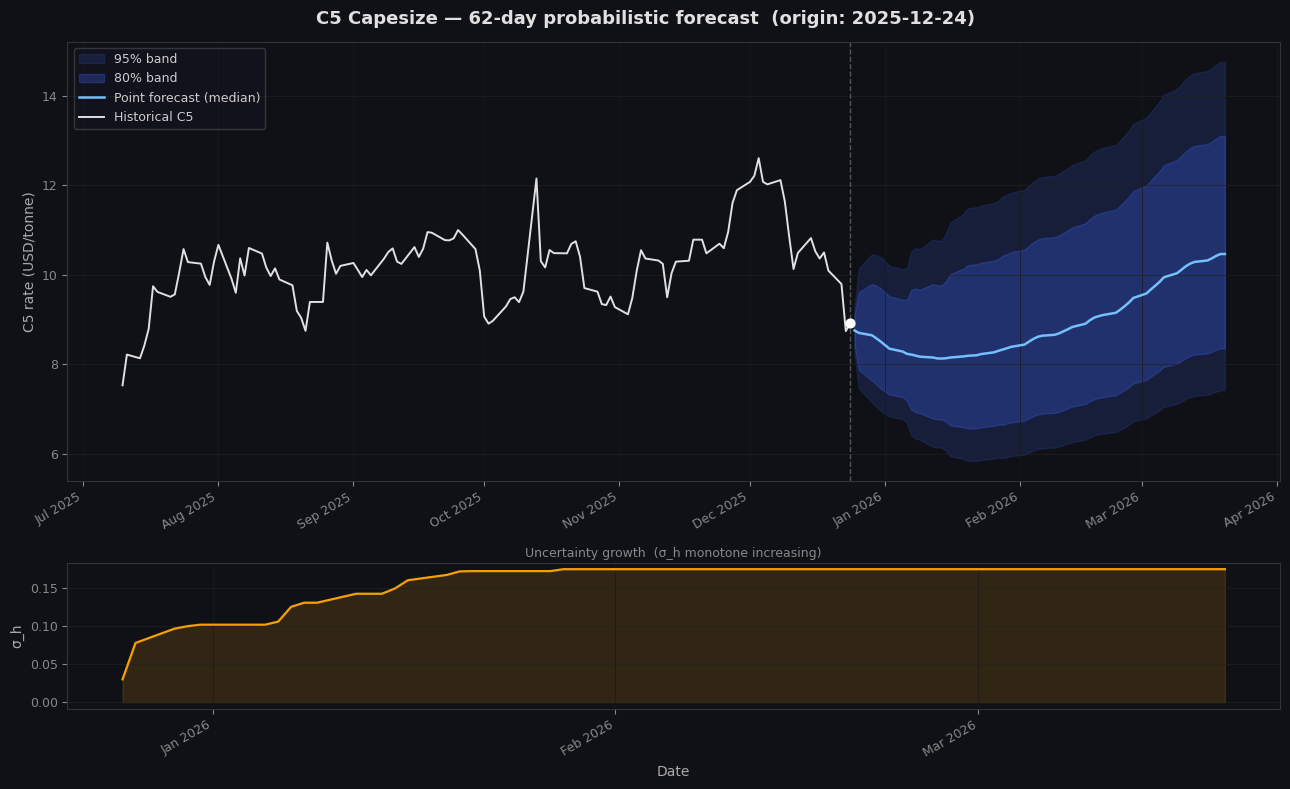

Plot saved → c5_forecast_cone.png


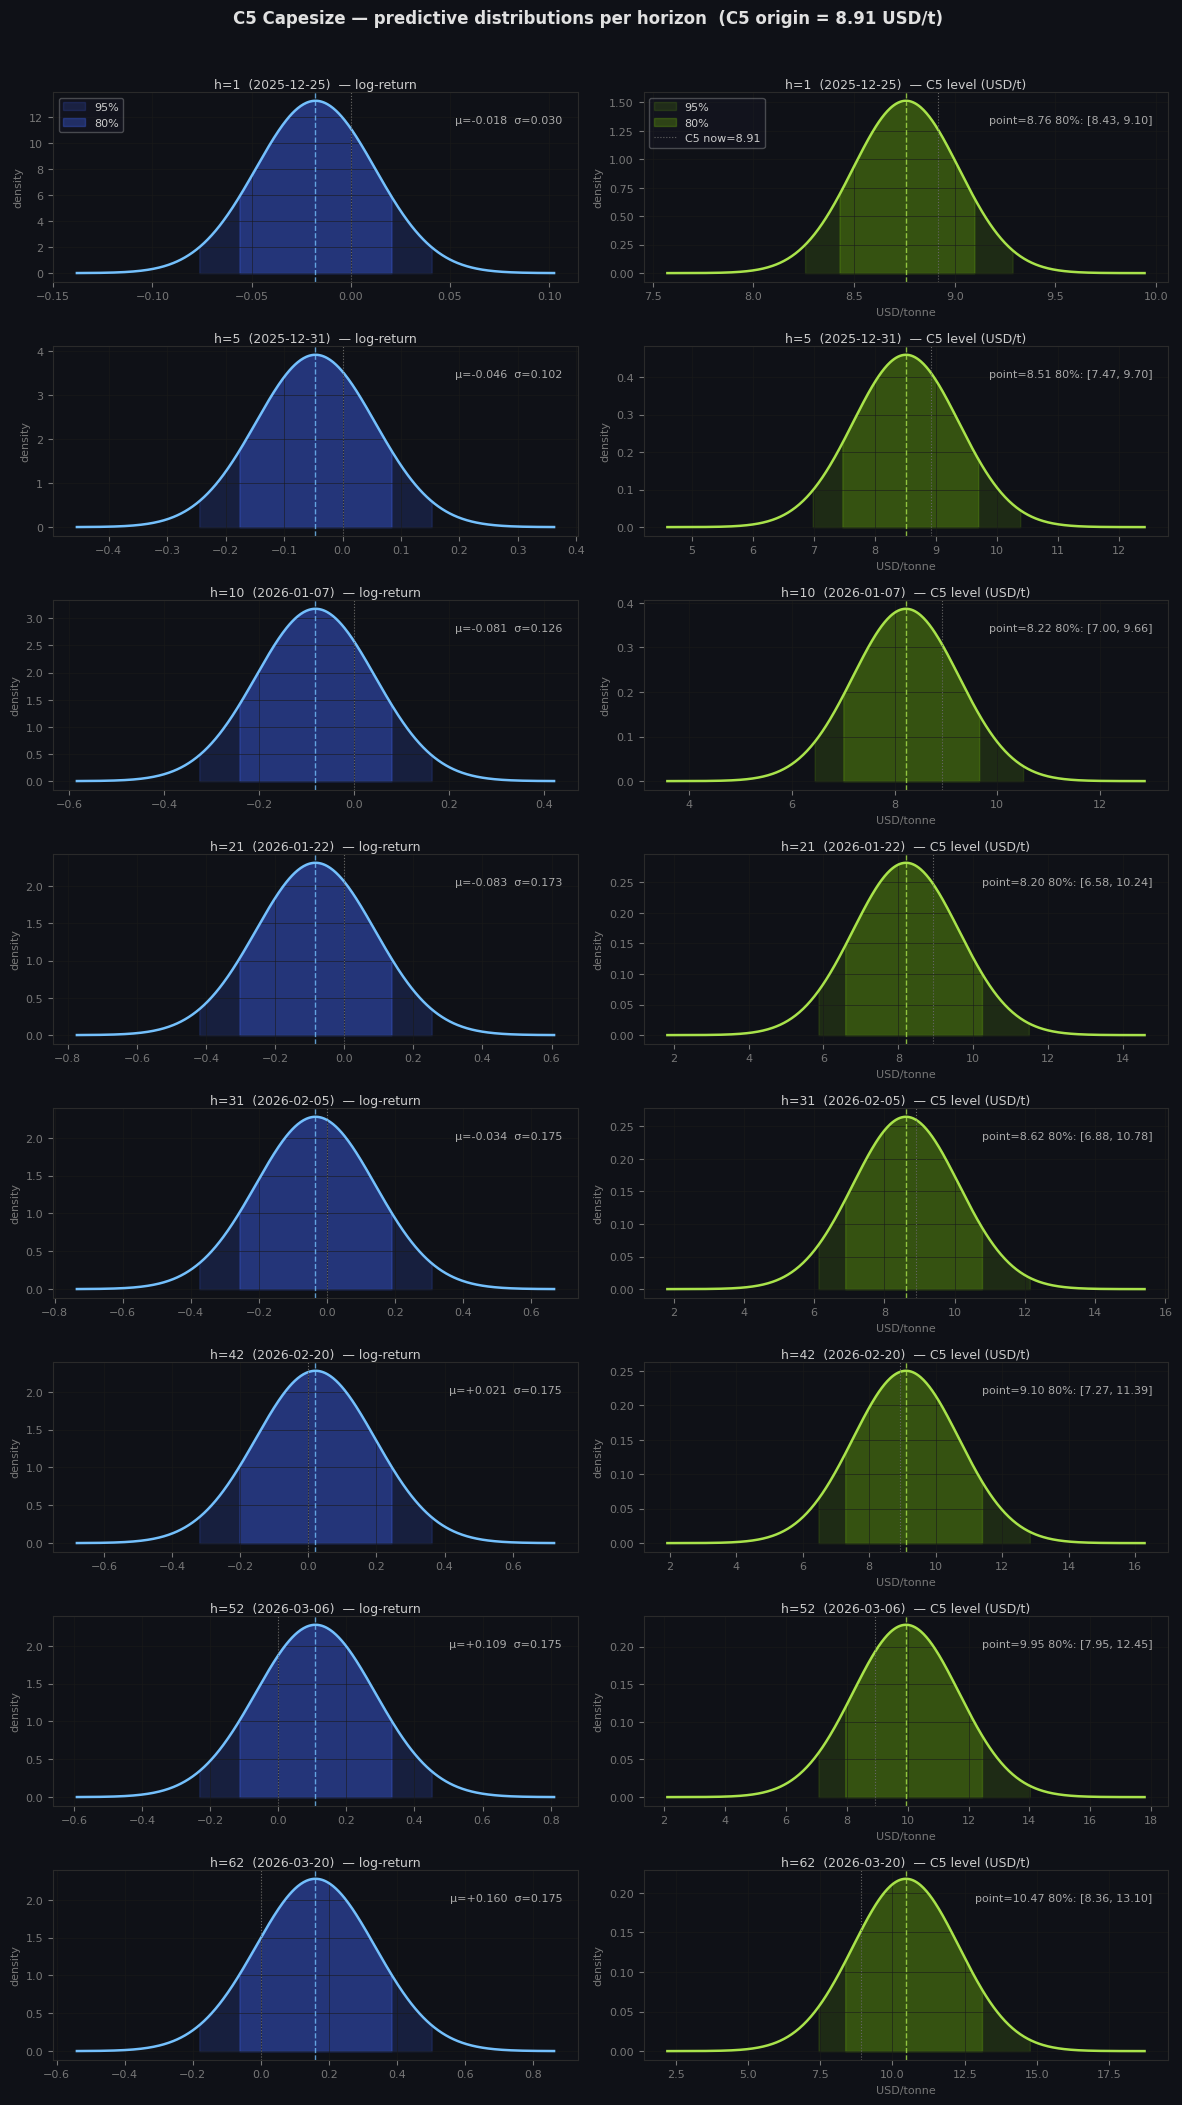

Saved → c5_distributions_grid.png


In [ ]:
plot_forecast(df_main, results["forecast"], history_days=120)
plot_distributions_grid(df_main, results["forecast"])
results["forecast"].to_csv("/content/drive/MyDrive/c5_forecast_62days.csv")

# NGBoost

In [ ]:
"""
Probabilistic Forecasting — C5 Capesize 62-day horizon  (NGBOOST VERSION)
==========================================================================
NGBoost predicts distribution parameters (mu, sigma, nu) end-to-end.
No separate calibration step needed — the distribution is learned directly.

Distribution: StudentT (mu_h, sigma_h, nu_h) per horizon h = 1...62
Walk-forward OOS expanding window, step=21 (~72 origins)
Feature importance via SHAP on the base learner
"""

import numpy as np
import pandas as pd
import time
import warnings
warnings.filterwarnings("ignore")

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline      import Pipeline
from sklearn.isotonic      import IsotonicRegression
from scipy                 import stats


# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────

HORIZON    = 62
MIN_TRAIN  = 252
STEP       = 21
TARGET_COL = "C5_rate_USD_tonne"
N_PCA      = 27

Z_80 = stats.norm.ppf(0.90)
Z_95 = stats.norm.ppf(0.975)


# ─────────────────────────────────────────────────────────────────────────────
# INSTALL CHECK
# ─────────────────────────────────────────────────────────────────────────────

def check_install():
    try:
        import ngboost
        from ngboost.distns import Normal
        print(f"✓ NGBoost {ngboost.__version__} found")
    except ImportError:
        print("Installing ngboost...")
        import subprocess
        subprocess.run(["pip", "install", "ngboost", "-q"])
        print("✓ NGBoost installed")

check_install()

from ngboost            import NGBRegressor
from ngboost.distns  import Normal, LogNormal
from ngboost.scores  import MLE


# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — TARGET ENGINEERING
# ─────────────────────────────────────────────────────────────────────────────

def build_targets(df: pd.DataFrame, horizon: int = HORIZON) -> pd.DataFrame:
    """y_{t,h} = log(C5_{t+h} / C5_t) for h = 1...62"""
    prices  = df[TARGET_COL].values
    n       = len(prices)
    targets = np.full((n, horizon), np.nan)
    for h in range(1, horizon + 1):
        targets[:n - h, h - 1] = np.log(prices[h:] / prices[:n - h])
    cols = [f"target_h{h}" for h in range(1, horizon + 1)]
    return pd.DataFrame(targets, index=df.index, columns=cols)


def get_feature_cols(df: pd.DataFrame) -> list:
    exclude = {TARGET_COL}
    exclude.update([c for c in df.columns if c.startswith("target_h")])
    return [c for c in df.columns
            if c not in exclude and pd.api.types.is_numeric_dtype(df[c])]


# ─────────────────────────────────────────────────────────────────────────────
# PREPROCESSING — StandardScaler + PCA (no model inside, NGBoost handles fit)
# ─────────────────────────────────────────────────────────────────────────────

def make_preprocessor(n_pca: int = N_PCA) -> Pipeline:
    return Pipeline([
        ("scaler", StandardScaler()),
        ("pca",    PCA(n_components=n_pca, random_state=42)),
    ])


def make_ngb_model(dist=Normal) -> NGBRegressor:
    """
    NGBoost with Normal or TDist distribution.
    n_estimators=200 balances speed vs accuracy for walk-forward.
    learning_rate=0.05 standard for NGBoost.
    """
    return NGBRegressor(
        Dist            = dist,
        Score           = MLE,
        n_estimators    = 200,
        learning_rate   = 0.05,
        minibatch_frac  = 1.0,
        col_sample      = 0.8,
        verbose         = False,
        random_state    = 42,
    )


# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — WALK-FORWARD FORECASTS
# NGBoost predicts distribution params directly — no separate sigma calibration
# ─────────────────────────────────────────────────────────────────────────────

def walk_forward_ngboost(
    df        : pd.DataFrame,
    targets   : pd.DataFrame,
    horizon   : int  = HORIZON,
    min_train : int  = MIN_TRAIN,
    step      : int  = STEP,
    dist      : type = Normal,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    For each origin t, fits one NGBRegressor per horizon h.
    NGBoost directly outputs distribution parameters:
      - Normal:  (mu, sigma)
      - TDist:   (mu, sigma, nu)  ← richer, captures fat tails

    Returns
    -------
    mu_df    : (n_origins, 62) — predicted means
    sigma_df : (n_origins, 62) — predicted sigmas (from NGBoost, not post-hoc)
    act_df   : (n_origins, 62) — actual log-returns
    """
    feature_cols = get_feature_cols(df)
    X = df[feature_cols].values.astype(np.float64)
    Y = targets[[f"target_h{h}" for h in range(1, horizon+1)]].values
    n = len(df)

    origins   = list(range(min_train, n - horizon, step))
    n_origins = len(origins)

    mu_mat    = np.full((n_origins, horizon), np.nan)
    sigma_mat = np.full((n_origins, horizon), np.nan)
    act_mat   = np.full((n_origins, horizon), np.nan)
    idx_list  = []

    dist_name = dist.__name__
    print(f"NGBoost walk-forward | dist={dist_name} | "
          f"{n_origins} origins | step={step}")
    print(f"Preprocessor: StandardScaler → PCA({N_PCA})")
    t0 = time.time()

    for i, t in enumerate(origins):
        idx_val  = df.index[t]
        date_str = idx_val.date() if hasattr(idx_val, "date") else str(idx_val)[:10]

        X_tr = X[:t];  Y_tr = Y[:t]
        valid = (~np.isnan(Y_tr).any(axis=1)) & (~np.isnan(X_tr).any(axis=1))

        if valid.sum() < 60:
            idx_list.append(idx_val); continue

        # Fit preprocessor on training data
        pre = make_preprocessor()
        X_tr_pca = pre.fit_transform(X_tr[valid])
        x_t_pca  = pre.transform(X[t].reshape(1, -1))

        if np.isnan(x_t_pca).any():
            idx_list.append(idx_val); continue

        # One NGBoost model per horizon
        for h in range(1, horizon + 1):
            y_h = Y_tr[valid, h - 1]
            if np.isnan(y_h).any():
                continue

            ngb = make_ngb_model(dist=dist)
            ngb.fit(X_tr_pca, y_h)

            pred_dist = ngb.pred_dist(x_t_pca)
            mu_mat[i, h-1]    = pred_dist.loc[0]      # mean
            sigma_mat[i, h-1] = pred_dist.scale[0]    # std

        act_mat[i] = Y[t]

        elapsed = time.time() - t0
        eta     = (elapsed / (i + 1)) * (n_origins - i - 1)
        print(f"  [{i+1:2d}/{n_origins}] {date_str}  "
              f"elapsed={elapsed/60:.1f}min  ETA={eta/60:.1f}min")
        idx_list.append(idx_val)

    h_cols   = [f"h{h}" for h in range(1, horizon + 1)]
    mu_df    = pd.DataFrame(mu_mat,    index=idx_list, columns=h_cols)
    sigma_df = pd.DataFrame(sigma_mat, index=idx_list, columns=h_cols)
    act_df   = pd.DataFrame(act_mat,   index=idx_list, columns=h_cols)

    total = time.time() - t0
    print(f"\nDone. {total/60:.1f}min | Shape: {mu_df.shape}")
    return mu_df, sigma_df, act_df


# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 — ENFORCE MONOTONE SIGMA
# (NGBoost gives per-origin sigma, we aggregate and enforce monotonicity)
# ─────────────────────────────────────────────────────────────────────────────

def aggregate_sigma(
    sigma_df : pd.DataFrame,
    horizon  : int = HORIZON,
) -> np.ndarray:
    """
    Aggregate predicted sigmas across OOS origins:
        sigma_h = mean(sigma_df[:, h])
    Then enforce monotone increase via isotonic regression.
    """
    h_cols    = [f"h{h}" for h in range(1, horizon + 1)]
    raw_sigma = sigma_df[h_cols].mean(axis=0).values

    iso            = IsotonicRegression(increasing=True)
    sigma_monotone = iso.fit_transform(np.arange(1, horizon + 1), raw_sigma)

    print(f"\n{'h':>4}  {'raw_σ (mean)':>13}  {'monotone_σ':>12}")
    for h in [1, 5, 10, 21, 42, 62]:
        print(f"  {h:4d}  {raw_sigma[h-1]:13.4f}  {sigma_monotone[h-1]:12.4f}")

    return sigma_monotone


# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 — LIVE FORECAST
# ─────────────────────────────────────────────────────────────────────────────

def forecast_distribution_ngb(
    df       : pd.DataFrame,
    sigma    : np.ndarray,
    horizon  : int  = HORIZON,
    origin_t : int  = -1,
    dist     : type = Normal,
) -> pd.DataFrame:
    """
    Train NGBoost on full history, predict 62-day distribution.
    Uses aggregated sigma (monotone) for final bands.
    """
    feature_cols = get_feature_cols(df)
    targets      = build_targets(df, horizon)
    h_cols_y     = [f"target_h{h}" for h in range(1, horizon + 1)]
    X            = df[feature_cols].values.astype(np.float64)
    Y            = targets[h_cols_y].values

    t    = origin_t if origin_t >= 0 else len(df) - 1
    C5_t = df[TARGET_COL].iloc[t]

    valid = (~np.isnan(Y[:t]).any(axis=1)) & (~np.isnan(X[:t]).any(axis=1))

    pre      = make_preprocessor()
    X_tr_pca = pre.fit_transform(X[:t][valid])
    x_t_pca  = pre.transform(X[t].reshape(1, -1))

    date_str = df.index[t].date() if hasattr(df.index[t], "date") else str(df.index[t])[:10]
    print(f"Live forecast from {date_str}, C5={C5_t:.2f}")

    rows = []
    for h in range(1, horizon + 1):
        y_h = Y[:t][valid, h - 1]
        ngb = make_ngb_model(dist=dist)
        ngb.fit(X_tr_pca, y_h)

        pred_dist = ngb.pred_dist(x_t_pca)
        mu_h      = float(pred_dist.loc[0])
        sig_h     = sigma[h - 1]   # use monotone aggregated sigma
        fdate     = df.index[t] + pd.offsets.BDay(h)

        lo80 = mu_h - Z_80 * sig_h;  hi80 = mu_h + Z_80 * sig_h
        lo95 = mu_h - Z_95 * sig_h;  hi95 = mu_h + Z_95 * sig_h

        rows.append({
            "horizon"     : h,
            "date"        : fdate,
            "mu_logret"   : mu_h,
            "sigma_logret": sig_h,
            "C5_point"    : C5_t * np.exp(mu_h),
            "C5_lower80"  : C5_t * np.exp(lo80),
            "C5_upper80"  : C5_t * np.exp(hi80),
            "C5_lower95"  : C5_t * np.exp(lo95),
            "C5_upper95"  : C5_t * np.exp(hi95),
        })

    return pd.DataFrame(rows).set_index("horizon")


# ─────────────────────────────────────────────────────────────────────────────
# EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

def crps_gaussian(mu, sigma, y):
    if sigma <= 0 or np.isnan(y): return np.nan
    z = (y - mu) / sigma
    return sigma * (z * (2*stats.norm.cdf(z) - 1) +
                    2*stats.norm.pdf(z) - 1/np.sqrt(np.pi))


def winkler_score(lo, hi, y, alpha):
    width = hi - lo
    if y < lo: return width + (2/alpha) * (lo - y)
    if y > hi: return width + (2/alpha) * (y - hi)
    return width


def evaluate_ngb(
    mu_df    : pd.DataFrame,
    act_df   : pd.DataFrame,
    sigma    : np.ndarray,
    horizon  : int = HORIZON,
) -> pd.DataFrame:
    records = []
    for h in range(1, horizon + 1):
        col   = f"h{h}"
        sig_h = sigma[h - 1]
        mu_v  = mu_df[col].dropna()
        act_v = act_df[col].reindex(mu_v.index).dropna()
        mu_v  = mu_v.reindex(act_v.index)
        if len(act_v) == 0: continue

        lo80 = mu_v - Z_80 * sig_h;  hi80 = mu_v + Z_80 * sig_h
        lo95 = mu_v - Z_95 * sig_h;  hi95 = mu_v + Z_95 * sig_h

        crps = [crps_gaussian(m, sig_h, y) for m, y in zip(mu_v, act_v)]
        w80  = [winkler_score(l, u, y, 0.20) for l, u, y in zip(lo80, hi80, act_v)]
        w95  = [winkler_score(l, u, y, 0.05) for l, u, y in zip(lo95, hi95, act_v)]

        records.append({
            "horizon"    : h,
            "sigma"      : sig_h,
            "CRPS"       : np.nanmean(crps),
            "Winkler_80" : np.nanmean(w80),
            "Winkler_95" : np.nanmean(w95),
            "Coverage_80": ((act_v >= lo80) & (act_v <= hi80)).mean(),
            "Coverage_95": ((act_v >= lo95) & (act_v <= hi95)).mean(),
            "MAE_logret" : (mu_v - act_v).abs().mean(),
            "n_obs"      : len(act_v),
        })
    return pd.DataFrame(records).set_index("horizon")


# ─────────────────────────────────────────────────────────────────────────────
# FEATURE IMPORTANCE — SHAP on NGBoost base learner
# ─────────────────────────────────────────────────────────────────────────────

def extract_shap_importance(
    df       : pd.DataFrame,
    horizon  : int = HORIZON,
    min_train: int = MIN_TRAIN,
    step     : int = STEP,
    top_n    : int = 10,
    dist     : type = Normal,
) -> pd.DataFrame:
    try:
        import shap
    except ImportError:
        import subprocess
        subprocess.run(["pip", "install", "shap", "-q"])
        import shap

    feature_cols = get_feature_cols(df)
    X = df[feature_cols].values.astype(np.float64)
    Y = build_targets(df)[[f"target_h{h}" for h in range(1, horizon+1)]].values
    n = len(df)

    origins = list(range(min_train, n - horizon, step))
    t = origins[-1]
    date_str = df.index[t].date() if hasattr(df.index[t], "date") else str(df.index[t])[:10]
    print(f"SHAP importance at last origin: {date_str}")

    X_tr = X[:t];  Y_tr = Y[:t]
    valid = (~np.isnan(Y_tr).any(axis=1)) & (~np.isnan(X_tr).any(axis=1))

    pre      = make_preprocessor()
    X_tr_pca = pre.fit_transform(X_tr[valid])
    pca      = pre.named_steps["pca"]
    components = pca.components_   # (n_pca, n_features)

    # ── Helper: extract the last loc-tree from a fitted NGBRegressor ──────────
    def get_loc_tree(ngb_model):
        """
        Works across NGBoost versions:
          - ≥0.4: ngb.learners_ is a list of [loc_tree, scale_tree, ...]
          - older: ngb.f0_ + learners_ structure differs
        Falls back to inspecting available attributes.
        """
        # Try the modern attribute first
        if hasattr(ngb_model, "learners_"):
            # learners_ is list-of-lists: [[loc_tree, scale_tree], ...]
            # The last estimator in the loc component
            return ngb_model.learners_[0][-1]

        # Some builds store them under a different name
        for attr in ("base_models_", "estimators_", "_learners"):
            if hasattr(ngb_model, attr):
                container = getattr(ngb_model, attr)
                # Try [0][-1] pattern first
                try:
                    return container[0][-1]
                except (IndexError, TypeError):
                    try:
                        return container[-1]
                    except Exception:
                        pass

        raise AttributeError(
            f"Cannot locate base learner in NGBRegressor. "
            f"Available attrs: {[a for a in dir(ngb_model) if not a.startswith('__')]}"
        )

    records = []
    for h in [1, 5, 10, 21, 42, 62]:
        print(f"  Computing SHAP for h={h}...")
        y_h = Y_tr[valid, h - 1]
        ngb = make_ngb_model(dist=dist)
        ngb.fit(X_tr_pca, y_h)

        try:
            loc_tree   = get_loc_tree(ngb)
            explainer  = shap.TreeExplainer(loc_tree)
            shap_vals  = explainer.shap_values(X_tr_pca)     # (n, n_pca)
        except Exception as e:
            print(f"    TreeExplainer failed ({e}), falling back to KernelExplainer...")
            # KernelExplainer is slower but model-agnostic
            bg = shap.kmeans(X_tr_pca, 20)
            explainer = shap.KernelExplainer(
                lambda x: ngb.predict(x), bg
            )
            shap_vals = explainer.shap_values(X_tr_pca[:100])  # subsample for speed

        mean_shap  = np.abs(shap_vals).mean(axis=0)      # (n_pca,)

        # Project back to original features via PCA components
        feat_imp   = np.abs(mean_shap @ components)      # (n_features,)
        pct        = feat_imp / feat_imp.sum()

        top_idx = np.argsort(feat_imp)[::-1][:top_n]
        for rank, fidx in enumerate(top_idx, 1):
            records.append({
                "horizon"        : h,
                "rank"           : rank,
                "feature"        : feature_cols[fidx],
                "shap_importance": float(feat_imp[fidx]),
                "pct_of_total"   : float(pct[fidx]),
            })

    df_shap = pd.DataFrame(records)
    df_shap.to_csv("/content/drive/MyDrive/c5_shap_importance_ngboost.csv", index=False)
    print("\nSaved → c5_shap_importance_ngboost.csv")

    print("\n" + "=" * 65)
    print("TOP 5 FEATURES BY HORIZON (SHAP)")
    print("=" * 65)
    for h in [1, 5, 10, 21, 42, 62]:
        sub = df_shap[df_shap["horizon"] == h].head(5)
        print(f"\n  h={h:2d}:")
        for _, row in sub.iterrows():
            bar = "█" * int(row["pct_of_total"] * 200)
            print(f"    #{int(row['rank'])}  {row['feature']:<48} "
                  f"{row['pct_of_total']*100:5.1f}%  {bar}")

    return df_shap

# ─────────────────────────────────────────────────────────────────────────────
# PLOTS
# ─────────────────────────────────────────────────────────────────────────────

def plot_forecast_ngb(df, forecast, history_days=120):
    import matplotlib.pyplot as plt
    import matplotlib.dates  as mdates

    hist  = df[TARGET_COL].iloc[-history_days:]
    dates = pd.to_datetime(forecast["date"])

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(13, 8),
        gridspec_kw={"height_ratios": [3, 1]},
        facecolor="#0f1117",
    )
    origin_str = hist.index[-1].date() if hasattr(hist.index[-1], "date") \
                 else str(hist.index[-1])[:10]
    fig.suptitle(
        f"C5 Capesize — 62-day NGBoost probabilistic forecast  (origin: {origin_str})",
        color="#e0e0e0", fontsize=13, fontweight="bold", y=0.98,
    )
    for ax in (ax1, ax2):
        ax.set_facecolor("#0f1117")
        ax.tick_params(colors="#888", labelsize=9)
        for sp in ax.spines.values(): sp.set_edgecolor("#333")

    ax1.fill_between(dates, forecast["C5_lower95"], forecast["C5_upper95"],
                     color="#3b5bdb", alpha=0.18, label="95% band")
    ax1.fill_between(dates, forecast["C5_lower80"], forecast["C5_upper80"],
                     color="#3b5bdb", alpha=0.32, label="80% band")
    ax1.plot(dates, forecast["C5_point"], color="#74c0fc",
             linewidth=1.8, label="Point forecast (NGBoost μ)")
    ax1.plot(hist.index, hist.values, color="#e0e0e0",
             linewidth=1.4, label="Historical C5")
    ax1.axvline(hist.index[-1], color="#555", linewidth=1, linestyle="--")
    ax1.scatter([hist.index[-1]], [hist.values[-1]],
                color="white", s=40, zorder=5)
    ax1.set_ylabel("C5 rate (USD/tonne)", color="#aaa", fontsize=10)
    ax1.legend(loc="upper left", framealpha=0.2, labelcolor="#ccc",
               fontsize=9, facecolor="#1a1a2e")
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax1.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha="right")
    ax1.grid(axis="y", color="#222", linewidth=0.5)

    ax2.plot(dates, forecast["sigma_logret"], color="#f59f00",
             linewidth=1.6, label="σ_h (NGBoost)")
    ax2.fill_between(dates, 0, forecast["sigma_logret"],
                     color="#f59f00", alpha=0.15)
    ax2.set_ylabel("σ_h", color="#aaa", fontsize=10)
    ax2.set_title("Uncertainty growth (σ_h monotone)",
                  color="#888", fontsize=9, pad=4)
    ax2.legend(fontsize=8, labelcolor="#ccc",
               facecolor="#1a1a2e", framealpha=0.3)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax2.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")
    ax2.grid(axis="y", color="#222", linewidth=0.5)

    plt.tight_layout()
    plt.savefig("c5_forecast_ngboost.png", dpi=150,
                bbox_inches="tight", facecolor="#0f1117")
    plt.show()
    print("Saved → c5_forecast_ngboost.png")


def plot_distributions_grid_ngb(
    df      : pd.DataFrame,
    forecast: pd.DataFrame,
    horizons: list = [1, 5, 10, 21, 31, 42, 52, 62],
) -> None:
    import matplotlib.pyplot as plt

    mu_vec    = forecast["mu_logret"].values
    sigma_vec = forecast["sigma_logret"].values
    dates     = pd.to_datetime(forecast["date"])
    C5_0      = df[TARGET_COL].iloc[-1]
    n         = len(horizons)

    fig, axes = plt.subplots(n, 2, figsize=(12, 2.8 * n), facecolor="#0f1117")
    fig.suptitle(
        f"C5 — NGBoost predictive distributions  (C5={C5_0:.2f} USD/t)",
        color="#e0e0e0", fontsize=12, fontweight="bold", y=1.01,
    )
    for row, h in enumerate(horizons):
        mu  = mu_vec[h-1];  sig = sigma_vec[h-1]
        d   = dates.iloc[h-1].date()
        x   = np.linspace(mu - 4*sig, mu + 4*sig, 500)
        y   = stats.norm.pdf(x, mu, sig)
        lo80 = mu - Z_80*sig;  hi80 = mu + Z_80*sig
        lo95 = mu - Z_95*sig;  hi95 = mu + Z_95*sig

        for col_idx, (ax, space, color, title_sfx) in enumerate([
            (axes[row,0], "log-return", "#74c0fc", "log-return"),
            (axes[row,1], "level",      "#a9e34b", "C5 level"),
        ]):
            ax.set_facecolor("#0f1117")
            ax.tick_params(colors="#777", labelsize=8)
            for sp in ax.spines.values(): sp.set_edgecolor("#2a2a2a")

            if space == "log-return":
                ax.plot(x, y, color=color, linewidth=2)
                ax.fill_between(x, y, where=(x>=lo95)&(x<=hi95),
                                color=color, alpha=0.15, label="95%")
                ax.fill_between(x, y, where=(x>=lo80)&(x<=hi80),
                                color=color, alpha=0.35, label="80%")
                ax.axvline(mu, color=color, linewidth=1, linestyle="--", alpha=0.7)
                ax.axvline(0,  color="#555", linewidth=0.8, linestyle=":")
                ax.text(0.97, 0.88, f"μ={mu:+.3f}  σ={sig:.3f}",
                        transform=ax.transAxes, ha="right", va="top",
                        color="#aaa", fontsize=8)
                ax.set_xlabel("log-return", color="#777", fontsize=8)
            else:
                C5_pt  = C5_0 * np.exp(mu)
                C5_sig = C5_pt * sig
                x2     = np.linspace(max(0.5, C5_pt-4*C5_sig), C5_pt+4*C5_sig, 500)
                y2     = stats.norm.pdf(x2, C5_pt, C5_sig)
                ax.plot(x2, y2, color=color, linewidth=2)
                ax.fill_between(x2, y2,
                    where=(x2 >= C5_0*np.exp(lo95)) & (x2 <= C5_0*np.exp(hi95)),
                    color=color, alpha=0.15, label="95%")
                ax.fill_between(x2, y2,
                    where=(x2 >= C5_0*np.exp(lo80)) & (x2 <= C5_0*np.exp(hi80)),
                    color=color, alpha=0.35, label="80%")
                ax.axvline(C5_pt, color=color, linewidth=1, linestyle="--", alpha=0.7)
                ax.axvline(C5_0,  color="#555", linewidth=0.8, linestyle=":")
                ax.text(0.97, 0.88,
                        f"point={C5_pt:.2f}\n"
                        f"80%: [{C5_0*np.exp(lo80):.2f}, {C5_0*np.exp(hi80):.2f}]",
                        transform=ax.transAxes, ha="right", va="top",
                        color="#aaa", fontsize=8)
                ax.set_xlabel("USD/tonne", color="#777", fontsize=8)

            ax.set_title(f"h={h} ({d}) — {title_sfx}", color="#ccc", fontsize=9, pad=3)
            ax.set_ylabel("density", color="#777", fontsize=8)
            ax.grid(color="#1a1a1a", linewidth=0.4)
            if row == 0:
                ax.legend(fontsize=8, labelcolor="#ccc",
                          facecolor="#1a1a2e", framealpha=0.3, loc="upper left")

    plt.tight_layout()
    plt.savefig("c5_distributions_ngboost_grid.png", dpi=130,
                bbox_inches="tight", facecolor="#0f1117")
    plt.show()
    print("Saved → c5_distributions_ngboost_grid.png")


# ─────────────────────────────────────────────────────────────────────────────
# MAIN PIPELINE
# ─────────────────────────────────────────────────────────────────────────────

def run_probabilistic_pipeline_ngb(
    df   : pd.DataFrame,
    dist : type = Normal,
) -> dict:
    if not isinstance(df.index, pd.DatetimeIndex):
        if "Date" in df.columns: df = df.set_index("Date")
        df.index = pd.to_datetime(df.index)

    print("=" * 60)
    print("STEP 1 — Building targets")
    print("=" * 60)
    targets = build_targets(df)
    print(f"Target matrix shape: {targets.shape}")

    print("\n" + "=" * 60)
    print("STEP 2 — Walk-forward NGBoost forecasts")
    print("=" * 60)
    mu_df, sigma_df, act_df = walk_forward_ngboost(df, targets, dist=dist)

    print("\n" + "=" * 60)
    print("STEP 3 — Aggregate sigma (monotone)")
    print("=" * 60)
    sigma = aggregate_sigma(sigma_df)

    print("\n" + "=" * 60)
    print("STEP 4 — Evaluation")
    print("=" * 60)
    eval_df = evaluate_ngb(mu_df, act_df, sigma)
    print("\nKey horizons:")
    print(eval_df.loc[eval_df.index.isin([1, 5, 10, 21, 42, 62])].to_string())

    print("\n" + "=" * 60)
    print("STEP 4b — Live 62-day forecast")
    print("=" * 60)
    forecast = forecast_distribution_ngb(df, sigma, dist=dist)
    print(forecast[["C5_point","C5_lower80","C5_upper80",
                     "C5_lower95","C5_upper95"]].iloc[[0,4,9,20,41,61]])

    return {
        "mu_df"   : mu_df,
        "sigma_df": sigma_df,
        "act_df"  : act_df,
        "sigma"   : sigma,
        "eval_df" : eval_df,
        "forecast": forecast,
    }

✓ NGBoost 0.5.10 found


STEP 1 — Building targets
Target matrix shape: (1809, 62)

STEP 2 — Walk-forward NGBoost forecasts
NGBoost walk-forward | dist=Normal | 72 origins | step=21
Preprocessor: StandardScaler → PCA(27)
  [ 1/72] 2020-01-07  elapsed=3.3min  ETA=235.0min
  [ 2/72] 2020-02-05  elapsed=6.8min  ETA=236.7min
  [ 3/72] 2020-03-05  elapsed=10.3min  ETA=235.8min
  [ 4/72] 2020-04-03  elapsed=13.8min  ETA=235.1min
  [ 5/72] 2020-05-04  elapsed=17.6min  ETA=235.4min
  [ 6/72] 2020-06-02  elapsed=21.4min  ETA=235.0min
  [ 7/72] 2020-07-01  elapsed=25.2min  ETA=234.3min
  [ 8/72] 2020-07-30  elapsed=29.2min  ETA=233.6min
  [ 9/72] 2020-08-28  elapsed=33.3min  ETA=232.9min
  [10/72] 2020-09-28  elapsed=37.5min  ETA=232.2min
  [11/72] 2020-10-27  elapsed=41.7min  ETA=231.4min
  [12/72] 2020-11-25  elapsed=46.3min  ETA=231.5min
  [13/72] 2020-12-24  elapsed=51.1min  ETA=232.0min
  [14/72] 2021-01-22  elapsed=55.9min  ETA=231.6min
  [15/72] 2021-02-22  elapsed=60.6min  ETA=230.3min
  [16/72] 2021-03-23  elap

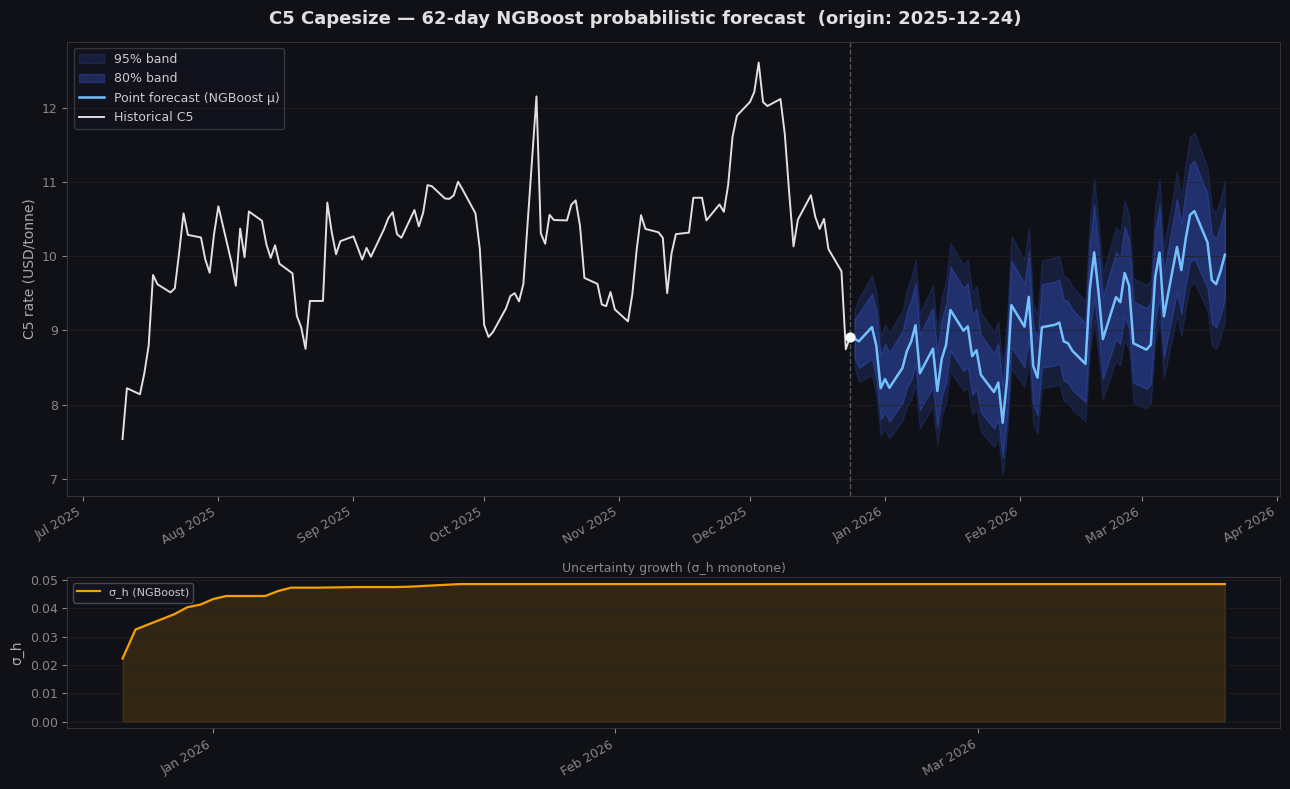

Saved → c5_forecast_ngboost.png


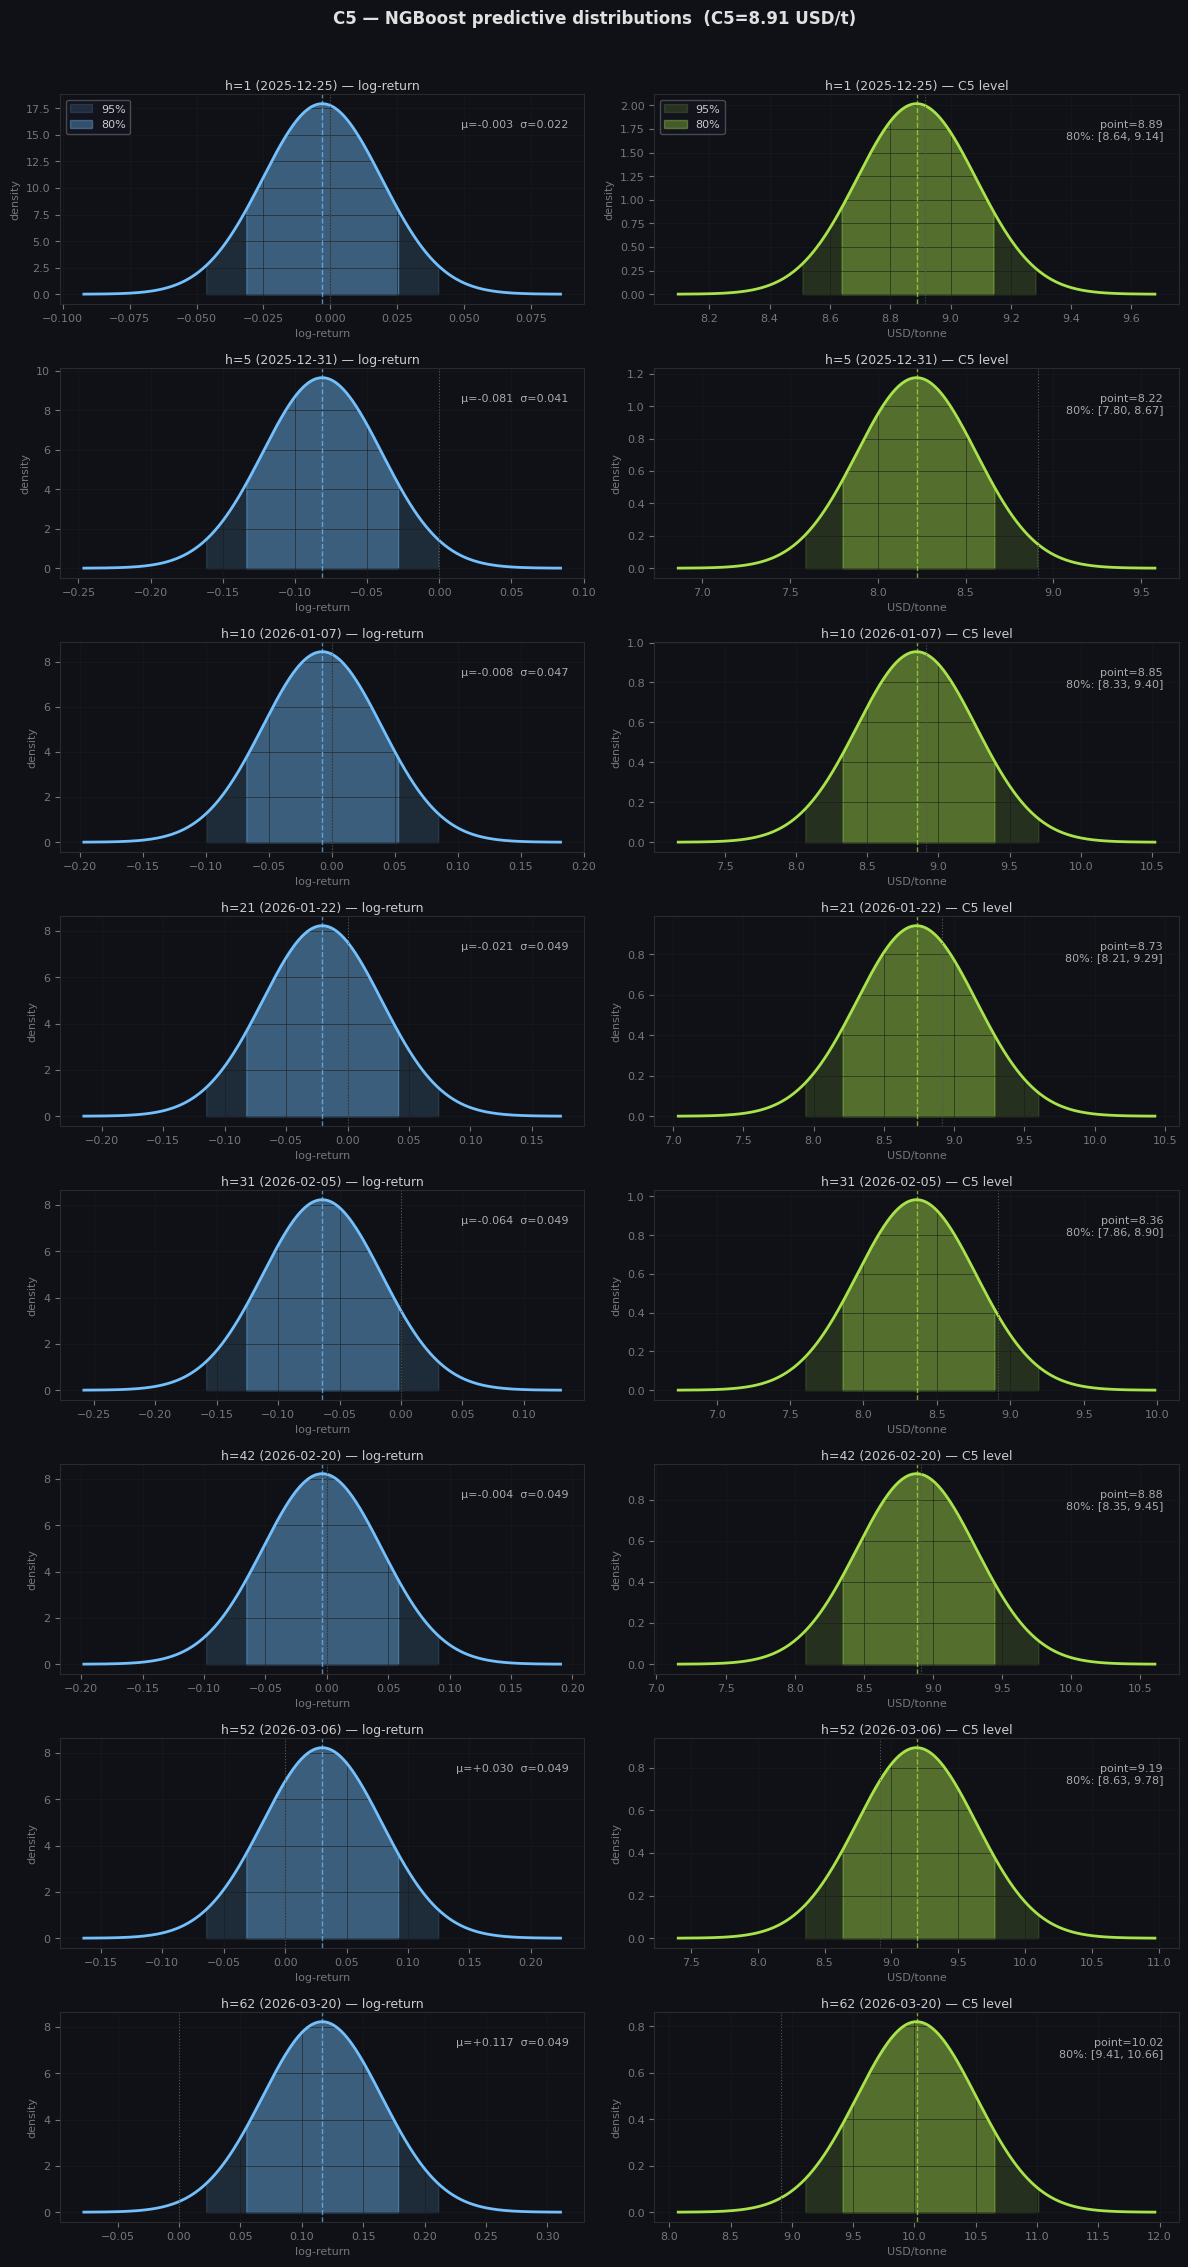

Saved → c5_distributions_ngboost_grid.png
SHAP importance at last origin: 2025-09-24
  Computing SHAP for h=1...
    TreeExplainer failed (Cannot locate base learner in NGBRegressor. Available attrs: ['Base', 'Dist', 'Manifold', 'Score', '_build_request_for_signature', '_check_feature_names', '_check_n_features', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_estimator_type', '_get_default_requests', '_get_doc_link', '_get_feature_importance', '_get_metadata_request', '_get_param_names', '_get_tags', '_more_tags', '_repr_html_', '_repr_html_inner', '_repr_mimebundle_', '_validate_data', '_validate_params', 'base_models', 'best_val_loss_itr', 'col_idxs', 'col_sample', 'early_stopping_rounds', 'evals_result', 'feature_importances_', 'fit', 'fit_base', 'fit_init_params_to_marginal', 'get_metadata_routing', 'get_params', 'init_params', 'learning_rate', 'line_search', 'minibatch_frac', 'multi_output', 'n_estimators', 'n_features', 'natural_gradient', 'partial_f

  0%|          | 0/100 [00:00<?, ?it/s]

  Computing SHAP for h=5...
    TreeExplainer failed (Cannot locate base learner in NGBRegressor. Available attrs: ['Base', 'Dist', 'Manifold', 'Score', '_build_request_for_signature', '_check_feature_names', '_check_n_features', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_estimator_type', '_get_default_requests', '_get_doc_link', '_get_feature_importance', '_get_metadata_request', '_get_param_names', '_get_tags', '_more_tags', '_repr_html_', '_repr_html_inner', '_repr_mimebundle_', '_validate_data', '_validate_params', 'base_models', 'best_val_loss_itr', 'col_idxs', 'col_sample', 'early_stopping_rounds', 'evals_result', 'feature_importances_', 'fit', 'fit_base', 'fit_init_params_to_marginal', 'get_metadata_routing', 'get_params', 'init_params', 'learning_rate', 'line_search', 'minibatch_frac', 'multi_output', 'n_estimators', 'n_features', 'natural_gradient', 'partial_fit', 'pred_dist', 'pred_param', 'predict', 'random_state', 'sample', 'scalings', 'sco

  0%|          | 0/100 [00:00<?, ?it/s]

  Computing SHAP for h=10...
    TreeExplainer failed (Cannot locate base learner in NGBRegressor. Available attrs: ['Base', 'Dist', 'Manifold', 'Score', '_build_request_for_signature', '_check_feature_names', '_check_n_features', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_estimator_type', '_get_default_requests', '_get_doc_link', '_get_feature_importance', '_get_metadata_request', '_get_param_names', '_get_tags', '_more_tags', '_repr_html_', '_repr_html_inner', '_repr_mimebundle_', '_validate_data', '_validate_params', 'base_models', 'best_val_loss_itr', 'col_idxs', 'col_sample', 'early_stopping_rounds', 'evals_result', 'feature_importances_', 'fit', 'fit_base', 'fit_init_params_to_marginal', 'get_metadata_routing', 'get_params', 'init_params', 'learning_rate', 'line_search', 'minibatch_frac', 'multi_output', 'n_estimators', 'n_features', 'natural_gradient', 'partial_fit', 'pred_dist', 'pred_param', 'predict', 'random_state', 'sample', 'scalings', 'sc

...

  Computing SHAP for h=42...
    TreeExplainer failed (Cannot locate base learner in NGBRegressor. Available attrs: ['Base', 'Dist', 'Manifold', 'Score', '_build_request_for_signature', '_check_feature_names', '_check_n_features', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_estimator_type', '_get_default_requests', '_get_doc_link', '_get_feature_importance', '_get_metadata_request', '_get_param_names', '_get_tags', '_more_tags', '_repr_html_', '_repr_html_inner', '_repr_mimebundle_', '_validate_data', '_validate_params', 'base_models', 'best_val_loss_itr', 'col_idxs', 'col_sample', 'early_stopping_rounds', 'evals_result', 'feature_importances_', 'fit', 'fit_base', 'fit_init_params_to_marginal', 'get_metadata_routing', 'get_params', 'init_params', 'learning_rate', 'line_search', 'minibatch_frac', 'multi_output', 'n_estimators', 'n_features', 'natural_gradient', 'partial_fit', 'pred_dist', 'pred_param', 'predict', 'random_state', 'sample', 'scalings', 'sc

  0%|          | 0/100 [00:00<?, ?it/s]

  Computing SHAP for h=62...
    TreeExplainer failed (Cannot locate base learner in NGBRegressor. Available attrs: ['Base', 'Dist', 'Manifold', 'Score', '_build_request_for_signature', '_check_feature_names', '_check_n_features', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_estimator_type', '_get_default_requests', '_get_doc_link', '_get_feature_importance', '_get_metadata_request', '_get_param_names', '_get_tags', '_more_tags', '_repr_html_', '_repr_html_inner', '_repr_mimebundle_', '_validate_data', '_validate_params', 'base_models', 'best_val_loss_itr', 'col_idxs', 'col_sample', 'early_stopping_rounds', 'evals_result', 'feature_importances_', 'fit', 'fit_base', 'fit_init_params_to_marginal', 'get_metadata_routing', 'get_params', 'init_params', 'learning_rate', 'line_search', 'minibatch_frac', 'multi_output', 'n_estimators', 'n_features', 'natural_gradient', 'partial_fit', 'pred_dist', 'pred_param', 'predict', 'random_state', 'sample', 'scalings', 'sc

  0%|          | 0/100 [00:00<?, ?it/s]


Saved → c5_shap_importance_ngboost.csv

TOP 5 FEATURES BY HORIZON (SHAP)

  h= 1:
    #1  China_New_Loan_bn_CNY_lag42d                       1.1%  ██
    #2  China_New_Loan_bn_CNY_lag62d                       1.0%  ██
    #3  AUS_IronOre_Exports_Mt_CLRK_lag42d                 0.9%  █
    #4  AUS_IronOre_Seaborne_Exports_Mt_SIN_lag42d         0.9%  █
    #5  China_New_Loan_bn_CNY_lag21d                       0.8%  █

  h= 5:
    #1  AUS_IronOre_Exports_Mt_CLRK_lag42d                 0.6%  █
    #2  AUS_IronOre_Seaborne_Exports_Mt_SIN_lag42d         0.6%  █
    #3  China_BFI_Prod_kt_lag42d                           0.6%  █
    #4  China_New_Loan_bn_CNY_lag21d                       0.6%  █
    #5  IronOre_Spot_CFR_NChina_USD_t_RealVol_21d          0.5%  █

  h=10:
    #1  AUS_IronOre_Exports_Mt_CLRK_lag42d                 0.7%  █
    #2  AUS_IronOre_Seaborne_Exports_Mt_SIN_lag42d         0.7%  █
    #3  C5_vs_C5_FFA_C5_2MON_spread                        0.6%  █
    #4  IronOre_Spot_CFR_N

In [ ]:
# Normal distribution
results = run_probabilistic_pipeline_ngb(df_main, dist=Normal)

plot_forecast_ngb(df_main, results["forecast"])
plot_distributions_grid_ngb(df_main, results["forecast"])
results["forecast"].to_csv("/content/drive/MyDrive/c5_forecast_62days_ngboost.csv")

df_shap = extract_shap_importance(df_main)